# *Detecting Dysarthria from Speech Audio Signals Using Advanced Deep Learning-Based Classification Techniques*

Dysarthria is a motor speech disorder that makes it difficult to form and pronounce words. Motor speech disorders occur when damage to your nervous system prevents you from fully controlling parts of your body that control speech, like your tongue, voice box (larynx) and jaw.

Dataset: https://www.kaggle.com/datasets/iamhungundji/dysarthria-detection

## *Folder Checking*

In [ ]:
# Check the list in the Folder
import os
os.listdir("/kaggle/input/dysarthria-detection/torgo_data")

['dysarthria_male',
 'non_dysarthria_male',
 'non_dysarthria_female',
 'dysarthria_female',
 'data.csv']

In [ ]:
# Store Directory in new variable
data_dir = '/kaggle/input/dysarthria-detection/torgo_data'

In [ ]:
# Check the dataset

import pandas as pd

# Load the CSV file
csv_path = os.path.join(data_dir, 'data.csv')
dys_df = pd.read_csv(csv_path)

dys_df.head()

,is_dysarthria,gender,filename
0,non_dysarthria,female,torgo_data/non_dysarthria_female/FC03_Session2...
1,non_dysarthria,female,torgo_data/non_dysarthria_female/FC02_Session3...
2,non_dysarthria,female,torgo_data/non_dysarthria_female/FC02_Session3...
3,non_dysarthria,female,torgo_data/non_dysarthria_female/FC03_Session2...
4,non_dysarthria,female,torgo_data/non_dysarthria_female/FC03_Session1...


## *Data Analysis for CSV File*

In [ ]:
# Check the data information
dys_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   is_dysarthria  2000 non-null   object
 1   gender         2000 non-null   object
 2   filename       2000 non-null   object
dtypes: object(3)
memory usage: 47.0+ KB


No missing values found in the dataset wuth 2000 records and 3 columns.

In [ ]:
# Check for duplicates
dys_df.duplicated().sum()

0

No duplicate data found.

In [ ]:
# Check the filename
dys_df['filename'][7]

'torgo_data/non_dysarthria_female/FC02_Session3_0341.wav'

In [ ]:
# Check total unqiue values
dys_df['is_dysarthria'].unique()

array(['non_dysarthria', 'dysarthria'], dtype=object)

### *Visualisation*

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Colours
colours = ['#5e80c2', '#4065a5', '#1d4c88', '#00346c']

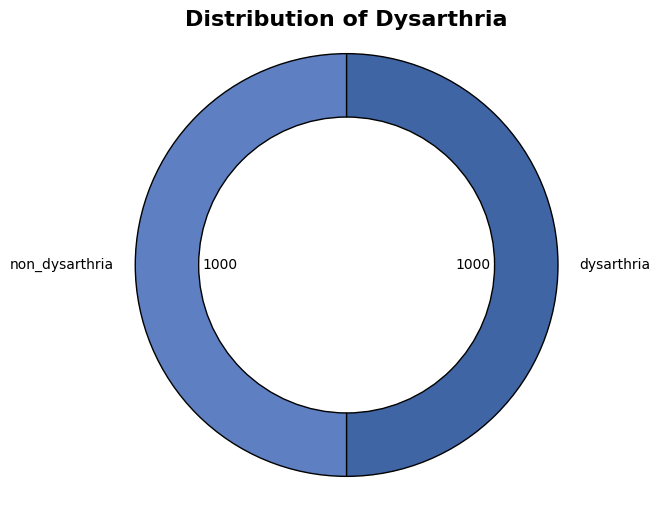

In [ ]:
# Make a donut plot for seeing the distribution of is_dysarthria

# Get the count distribution of is_dysarthria
dysarthria_counts = df['is_dysarthria'].value_counts()

# Plot
fig, ax = plt.subplots(figsize=(6,6))
ax.pie(dysarthria_counts, labels=dysarthria_counts.index, autopct=lambda p: f'{int(p * sum(dysarthria_counts) / 100)}',
       startangle=90, colors=colours, wedgeprops=dict(width=0.3, edgecolor="black"))

# Equal aspect ratio
ax.axis('equal')

plt.title('Distribution of Dysarthria', fontsize=16, fontweight='bold')
plt.show()

The donut chart shows an equal distribution. The dysarthria group contains 1000 instances, and the non-dysarthria group also contains 1000 instances, demonstrating a perfectly balanced dataset with a 1:1 ratio.

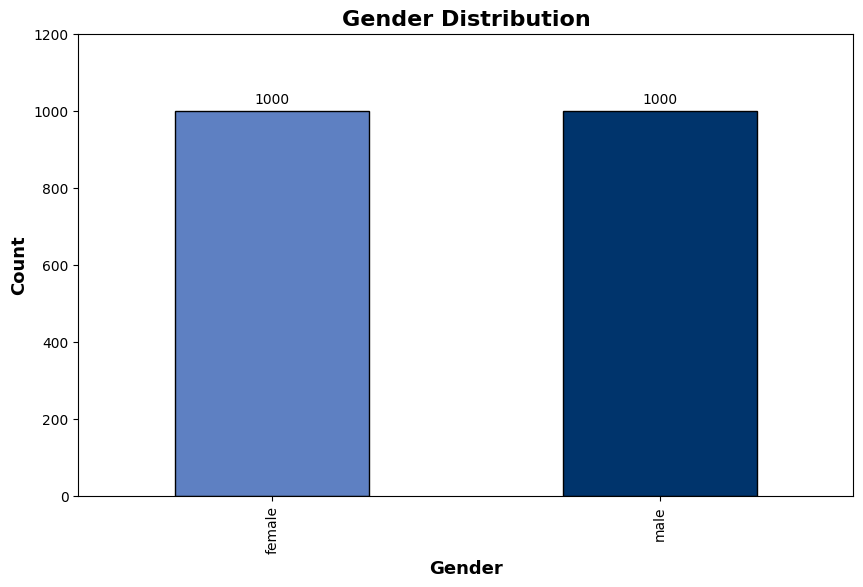

In [ ]:
# Make a bar plot for seeing the distribution of gender

# Count distribution
gender_counts = df['gender'].value_counts()

# Plotting
fig, ax = plt.subplots(figsize=(10,6))
bars = gender_counts.plot(kind='bar', color=['#5e80c2', '#00346c'], edgecolor='black', ax=ax)

# Adding annotations
for bar in bars.patches:
    ax.annotate(f'{bar.get_height()}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3),  # Offset the text slightly
                textcoords="offset points",
                ha='center', va='bottom')

# Adding title and labels
ax.set_title('Gender Distribution', fontsize=16, fontweight='bold')
ax.set_xlabel('Gender', fontsize=13, fontweight='bold')
ax.set_ylabel('Count', fontsize=13, fontweight='bold')

# Adding y limit
ax.set_ylim(0, 1200)

plt.show()

The "Gender Distribution" bar chart shows a balanced dataset with an equal number of female and male participants. There are 1000 female participants and 1000 male participants, indicating a perfectly even split between the two genders.

## *Analysis on Audio Data*

In [ ]:
import glob
from IPython.display import Audio
import librosa
import librosa.display
import numpy as np

In [ ]:
# Define the paths for the different categories
data_dir = "/kaggle/input/dysarthria-detection/torgo_data"
categories = ['dysarthria_male', 'non_dysarthria_male', 'non_dysarthria_female', 'dysarthria_female']

In [ ]:
# Check the audio files in each category
for category in categories:
    category_path = os.path.join(data_dir, category)
    audio_files = glob.glob(os.path.join(category_path, '*.wav'))

    print(f"Category: {category}")
    if audio_files:
        print(f"Found {len(audio_files)} audio files.")
        print("Sample files:", audio_files[:3])  # Print first 3 files as sample
    else:
        print("No audio files found.")
    print()

Category: dysarthria_male
Found 500 audio files.
Sample files: ['/kaggle/input/dysarthria-detection/torgo_data/dysarthria_male/M05_Session2_0075.wav', '/kaggle/input/dysarthria-detection/torgo_data/dysarthria_male/M02_Session1_0078.wav', '/kaggle/input/dysarthria-detection/torgo_data/dysarthria_male/M01_Session2_3_0057.wav']

Category: non_dysarthria_male
Found 500 audio files.
Sample files: ['/kaggle/input/dysarthria-detection/torgo_data/non_dysarthria_male/MC01_Session2_0233.wav', '/kaggle/input/dysarthria-detection/torgo_data/non_dysarthria_male/MC04_Session1_0149.wav', '/kaggle/input/dysarthria-detection/torgo_data/non_dysarthria_male/MC04_Session1_0576.wav']

Category: non_dysarthria_female
Found 500 audio files.
Sample files: ['/kaggle/input/dysarthria-detection/torgo_data/non_dysarthria_female/FC03_Session2_0319.wav', '/kaggle/input/dysarthria-detection/torgo_data/non_dysarthria_female/FC02_Session3_0349.wav', '/kaggle/input/dysarthria-detection/torgo_data/non_dysarthria_female/

In [ ]:
# Select first one audio file from the first category
category = categories[0]
category_path = os.path.join(data_dir, category)
audio_files = glob.glob(os.path.join(category_path, '*.wav'))

# Play the first audio file if available
if audio_files:
    audio_file = audio_files[0]
    print(f"Playing file: {audio_file}")
    display(Audio(audio_file))
else:
    print("No audio files found.")

Playing file: /kaggle/input/dysarthria-detection/torgo_data/dysarthria_male/M05_Session2_0075.wav


### *Count of each Dir*

In [ ]:
# Initialise a dictionary to store the counts
category_counts = {}

# Count the number of audio files in each folder
for category in categories:
    category_path = os.path.join(data_dir, category)
    file_count = len(os.listdir(category_path))
    category_counts[category] = file_count
    print(f"{category}: {file_count} files")

dysarthria_male: 500 files
non_dysarthria_male: 500 files
non_dysarthria_female: 500 files
dysarthria_female: 500 files


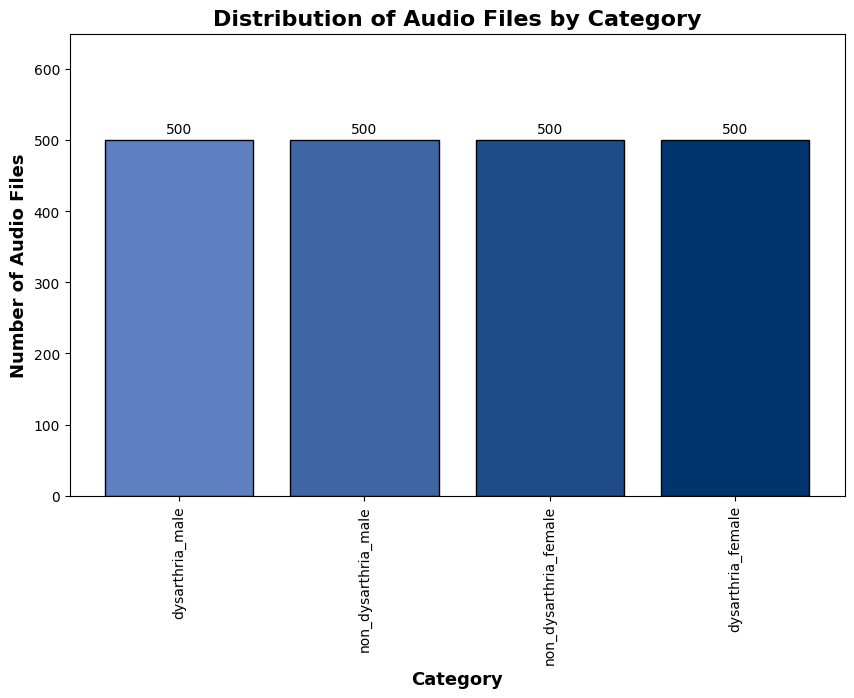

In [ ]:
# Plot the distribution
plt.figure(figsize=(10, 6))


# Make a Bar Plot
bars = plt.bar(category_counts.keys(), category_counts.values(), color=colours, edgecolor='black')


# Adding annotations
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),  # Offset the text slightly
                 textcoords="offset points",
                 ha='center', va='bottom')

# Adding title and labels
plt.title("Distribution of Audio Files by Category", fontsize=16, fontweight='bold')
plt.xlabel("Category", fontsize=13, fontweight='bold')
plt.ylabel("Number of Audio Files", fontsize=13, fontweight='bold')

# Rotating x-axis l
plt.xticks(rotation=90)

# Adding Y limit
plt.ylim(0, 650)

# Show plot
plt.show()

The bar chart shows an equal distribution across all four categories. Each category, including dysarthria male, non-dysarthria male, non-dysarthria female, and dysarthria female, contains exactly 500 audio files, indicating a perfectly balanced dataset.

In [ ]:
# Define the path to a single audio file
category = 'dysarthria_male'  # Example category
file_name = os.listdir(os.path.join(data_dir, category))[0]  # Select the first file
file_path = os.path.join(data_dir, category, file_name)

# Load the audio file using librosa
audio_data, sample_rate = librosa.load(file_path, sr=None)  # Load with the original sample rate

# Print basic information
print(f"File: {file_name}")
print(f"Sample Rate: {sample_rate}")
print(f"Duration: {librosa.get_duration(y=audio_data, sr=sample_rate):.2f} seconds")

File: M05_Session2_0075.wav
Sample Rate: 16000
Duration: 3.27 seconds


### *Waveforms*

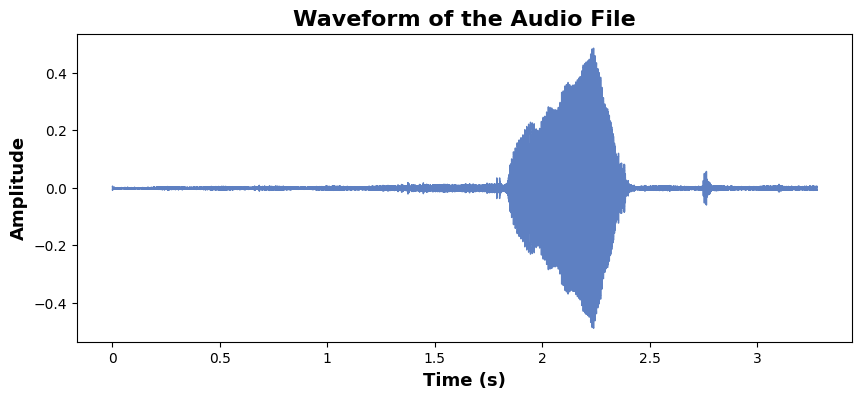

In [ ]:
# Plot the waveform
plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio_data, sr=sample_rate, color=colours[0])

# Adding title and labels
plt.title("Waveform of the Audio File", fontsize=16, fontweight='bold')
plt.xlabel("Time (s)", fontsize=13, fontweight='bold')
plt.ylabel("Amplitude", fontsize=13, fontweight='bold')

# Show the plot
plt.show()

The "Waveform of the Audio File" shows the audio signal over time. The amplitude remains near zero until approximately 1.75 seconds, then rapidly increases to a maximum of about 0.4 and a minimum of about -0.4, indicating a strong sound event. The sound ends around 2.7 seconds.

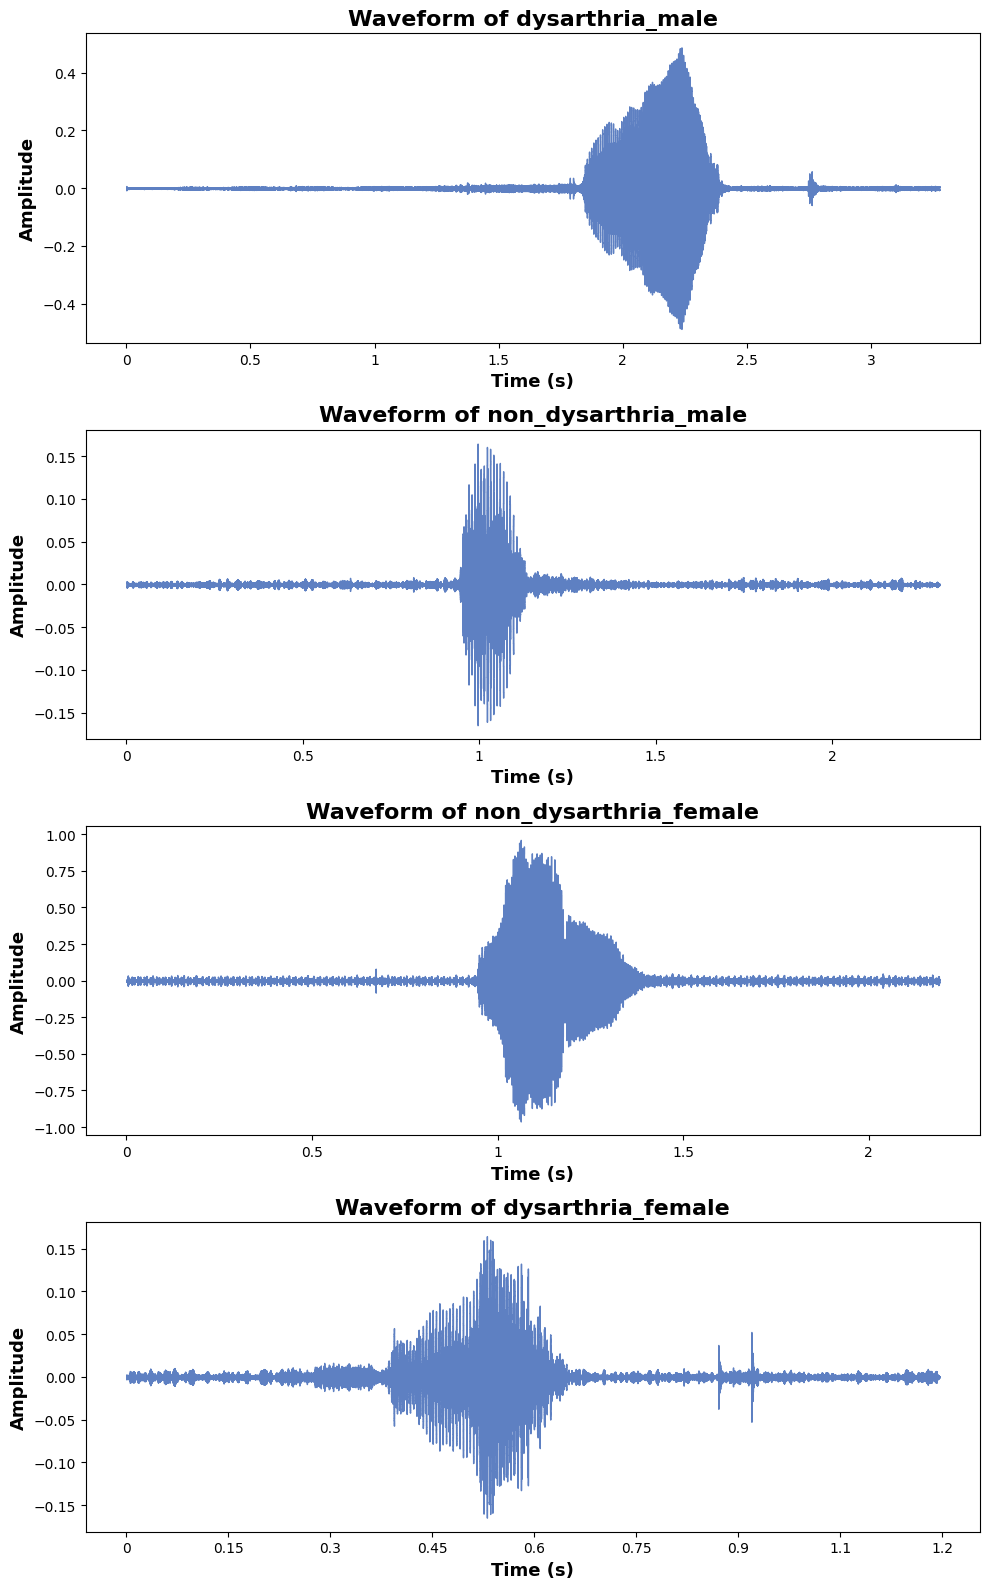

In [ ]:
# Create subplots for waveforms from each category
fig, axes = plt.subplots(len(categories), 1, figsize=(10, len(categories)*4))

# Plot waveform for one audio file from each category
for i, category in enumerate(categories):
    category_path = os.path.join(data_dir, category)
    audio_files = glob.glob(os.path.join(category_path, '*.wav'))

    if audio_files:
        # Load the first audio file in the category
        audio_file = audio_files[0]
        audio_data, sample_rate = librosa.load(audio_file, sr=None)

        # Plot the waveform on the corresponding subplot
        axes[i].set_title(f"Waveform of {category}", fontsize=16, fontweight='bold')
        librosa.display.waveshow(audio_data, sr=sample_rate, color=colours[0], ax=axes[i])
        axes[i].set_xlabel("Time (s)", fontsize=13, fontweight='bold')
        axes[i].set_ylabel("Amplitude", fontsize=13, fontweight='bold')
    else:
        axes[i].set_title(f"No audio files found for {category}")

# Adjust layout
plt.tight_layout()
plt.show()

The waveforms display audio characteristics for four categories. The "dysarthria male" waveform shows a major sound event from 1.75 to 2.5 seconds with a peak amplitude of 0.4. The "non-dysarthria male" waveform has a shorter duration from 0.8 to 1.5 seconds, with a lower peak amplitude of 0.15. The "non-dysarthria female" waveform shows a large, well-defined event from 0.75 to 1.75 seconds, reaching a significant peak amplitude of 1.0. Lastly, the "dysarthria female" waveform has a sound event from 0.3 to 0.7 seconds with a lower peak amplitude of 0.15, similar to the non-dysarthria male.

### *Spectrogram*

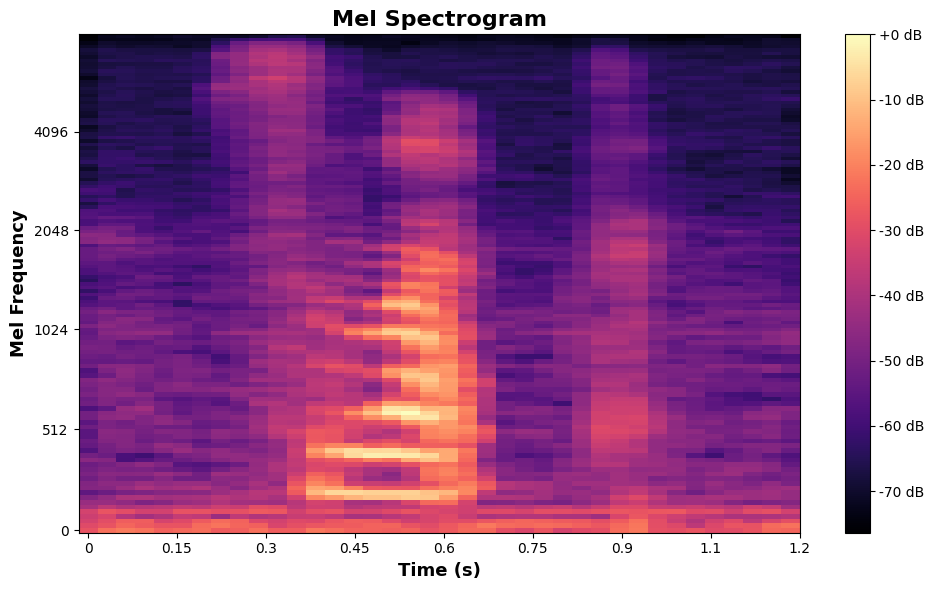

In [ ]:
# Compute and plot the Mel spectrogram
mel_spectrogram = librosa.feature.melspectrogram(y=audio_data, sr=sample_rate, n_mels=128)
mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)


# Make a plot
plt.figure(figsize=(10, 6))

# Display
librosa.display.specshow(mel_spectrogram_db, sr=sample_rate, x_axis='time', y_axis='mel')

# Add colourbar
plt.colorbar(format='%+2.0f dB')

# Add Title and Labels
plt.title("Mel Spectrogram", fontsize=16, fontweight='bold')
plt.xlabel("Time (s)", fontsize=13, fontweight='bold')
plt.ylabel("Mel Frequency", fontsize=13, fontweight='bold')

# Show plot
plt.tight_layout()
plt.show()

The Mel Spectrogram visualizes the audio's frequency and amplitude over time. The sound is present from 0 to 1.2 seconds, with two distinct high-intensity events. The first occurs around 0.5 seconds, with a strong presence from 512 Hz to 4096 Hz. A second, shorter event is visible at 0.9 seconds. The energy is highest, near 0 dB, in the central region of these events.

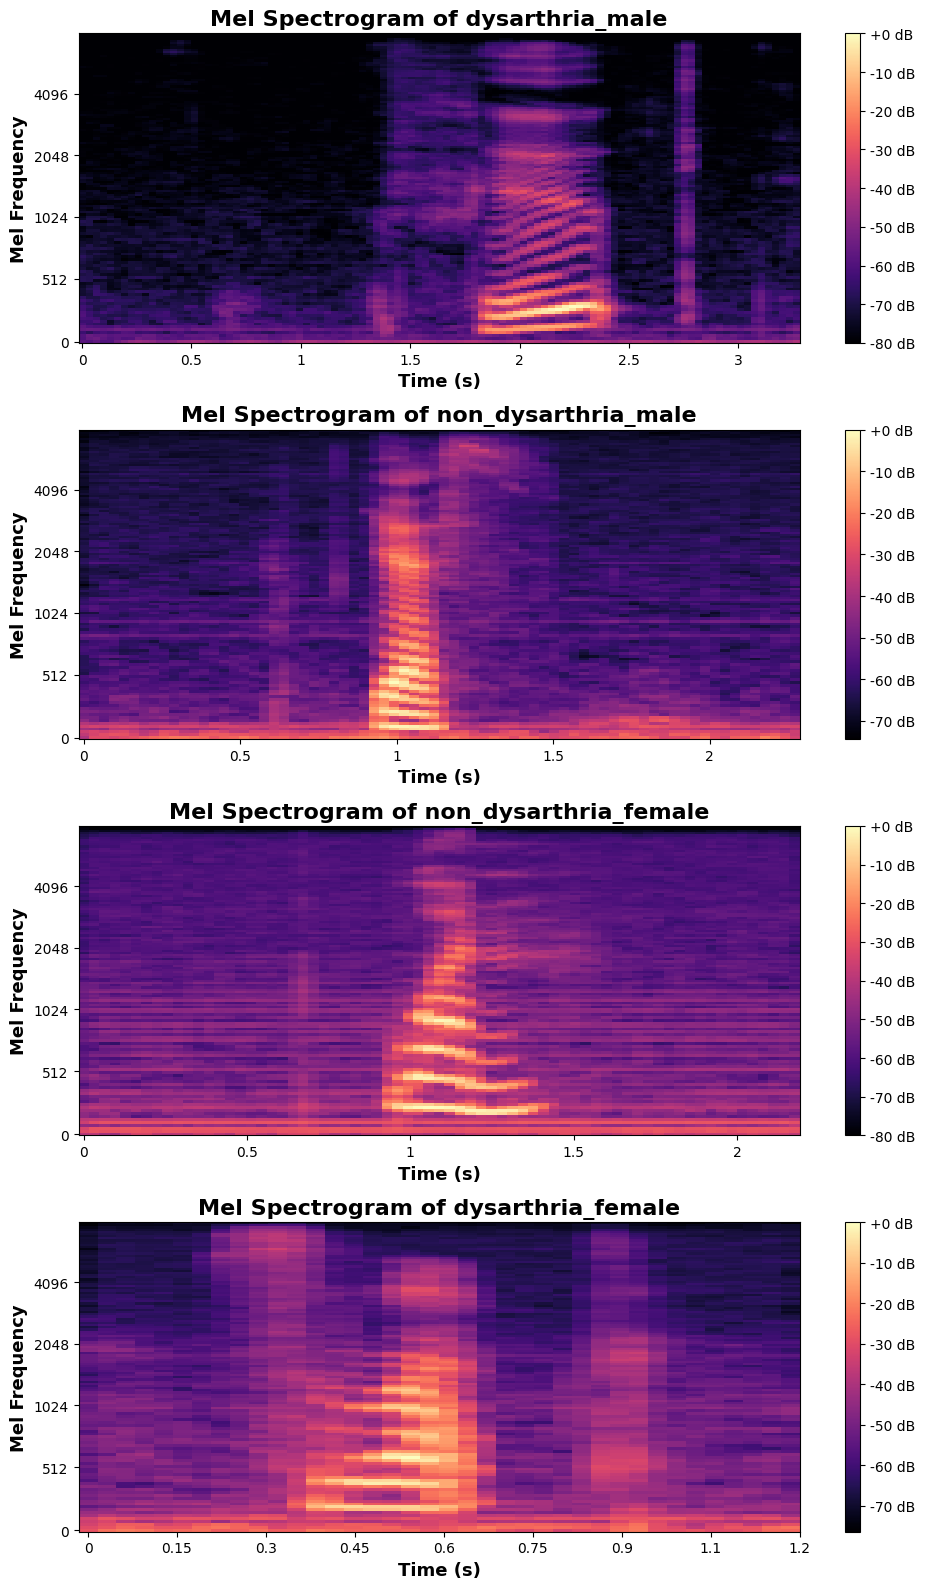

In [ ]:
# Create subplots for Mel spectrograms from each category
fig, axes = plt.subplots(len(categories), 1, figsize=(10, len(categories) * 4))

# Compute and plot Mel spectrogram for one audio file from each category
for i, category in enumerate(categories):
    category_path = os.path.join(data_dir, category)
    audio_files = glob.glob(os.path.join(category_path, '*.wav'))

    if audio_files:
        # Load the first audio file in the category
        audio_file = audio_files[0]
        audio_data, sample_rate = librosa.load(audio_file, sr=None)

        # Compute Mel spectrogram
        mel_spectrogram = librosa.feature.melspectrogram(y=audio_data, sr=sample_rate, n_mels=128)
        mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

        # Plot the Mel spectrogram on the corresponding subplot
        img = librosa.display.specshow(mel_spectrogram_db, sr=sample_rate, x_axis='time', y_axis='mel', ax=axes[i])
        axes[i].set_title(f"Mel Spectrogram of {category}", fontsize=16, fontweight='bold')
        axes[i].set_xlabel("Time (s)", fontsize=13, fontweight='bold')
        axes[i].set_ylabel("Mel Frequency", fontsize=13, fontweight='bold')

        # Add a colorbar to each subplot
        fig.colorbar(img, ax=axes[i], format='%+2.0f dB')
    else:
        axes[i].set_title(f"No audio files found for {category}")

# Adjust layout
plt.tight_layout()
plt.show()


The mel spectrograms show frequency distributions for different audio files. The "dysarthria male" plot displays a strong, sustained frequency from 1.75 to 2.5 seconds, with significant energy up to 4096 Hz. The "non-dysarthria male" plot shows a clear frequency pattern from 0.8 to 1.5 seconds, with strong energy concentrated below 4096 Hz. The "non-dysarthria female" plot has the most intense energy, reaching close to 0 dB, in a distinct pattern from 0.75 to 1.75 seconds, spanning all frequencies shown. Lastly, the "dysarthria female" plot shows less defined patterns, with energy from 0.4 to 0.7 seconds, with its highest energy below 2048 Hz.

### *Zero-Crossing Rate and Spectral Centroid*

In [ ]:
# Extract some audio features (e.g., Zero-Crossing Rate and Spectral Centroid)
zcr = librosa.feature.zero_crossing_rate(audio_data)
spectral_centroid = librosa.feature.spectral_centroid(y=audio_data, sr=sample_rate)

print(f"Mean Zero-Crossing Rate: {np.mean(zcr):.4f}")
print(f"Mean Spectral Centroid: {np.mean(spectral_centroid):.4f} Hz")

Mean Zero-Crossing Rate: 0.0937
Mean Spectral Centroid: 1679.7173 Hz


The mean zero-crossing rate is 0.0937 indicating moderate noisiness, while the mean spectral centroid is 1679.7173 Hz suggesting brightness.


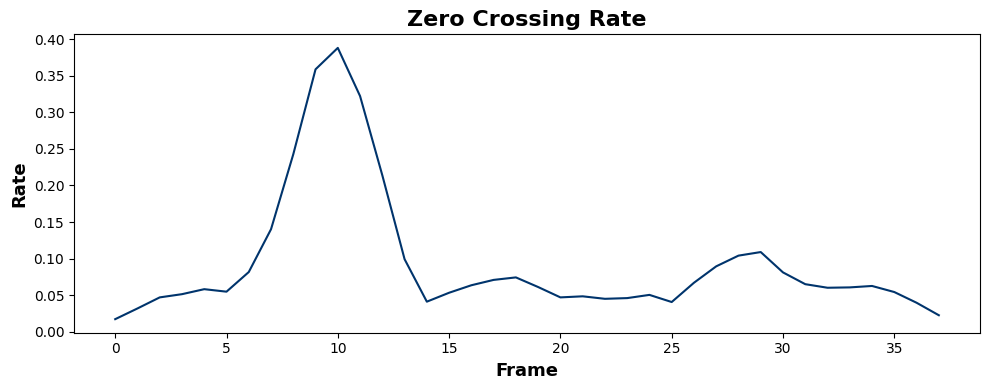

In [ ]:
# Compute zero crossing rate
zero_crossing_rate = librosa.feature.zero_crossing_rate(audio_data)[0]

# Plot the zero crossing rate
plt.figure(figsize=(10, 4))
plt.plot(zero_crossing_rate, color=colours[3])

# Adding title and labels
plt.title("Zero Crossing Rate", fontsize=16, fontweight='bold')
plt.xlabel("Frame", fontsize=13, fontweight='bold')
plt.ylabel("Rate", fontsize=13, fontweight='bold')

# Show plot
plt.tight_layout()
plt.show()

The "Zero Crossing Rate" plot shows the rate of signal sign changes over time. The rate starts low, near 0.02, then rises sharply. It reaches a maximum of about 0.39 at frame 10. The rate then drops significantly to a minimum of about 0.04 at frame 13 before a smaller peak occurs around frame 29, with a rate of 0.11.

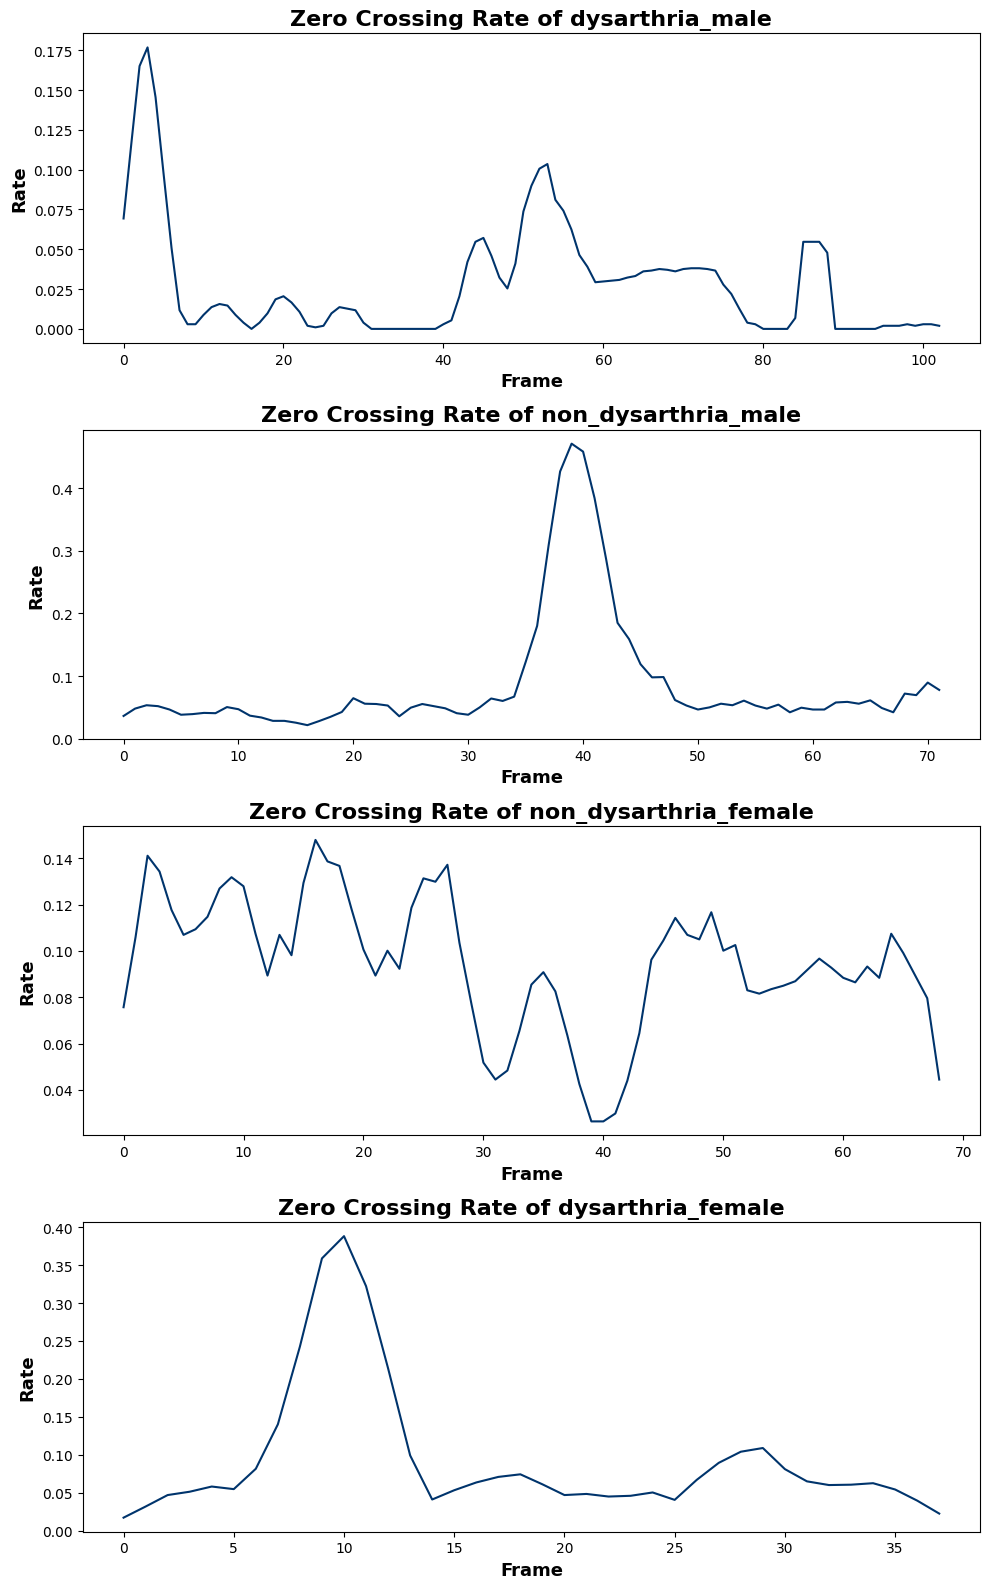

In [ ]:
# Create subplots for zero crossing rates from each category
fig, axes = plt.subplots(len(categories), 1, figsize=(10, len(categories) * 4))

# Compute and plot zero crossing rate for one audio file from each category
for i, category in enumerate(categories):
    category_path = os.path.join(data_dir, category)
    audio_files = glob.glob(os.path.join(category_path, '*.wav'))

    if audio_files:
        # Load the first audio file in the category
        audio_file = audio_files[0]
        audio_data, sample_rate = librosa.load(audio_file, sr=None)

        # Compute zero crossing rate
        zero_crossing_rate = librosa.feature.zero_crossing_rate(audio_data)[0]

        # Plot the zero crossing rate on the corresponding subplot
        axes[i].plot(zero_crossing_rate, color=colours[3])

        # Add Title and Labels
        axes[i].set_title(f"Zero Crossing Rate of {category}", fontsize=16, fontweight='bold')
        axes[i].set_xlabel("Frame", fontsize=13, fontweight='bold')
        axes[i].set_ylabel("Rate", fontsize=13, fontweight='bold')
    else:
        axes[i].set_title(f"No audio files found for {category}")

# Adjust layout
plt.tight_layout()
plt.show()

The plots show zero-crossing rates for different audio categories. The "dysarthria male" plot has a initial high peak of 0.175 near frame 5, a lower peak of 0.1 around frame 50, and a small peak of 0.05 around frame 85. The "non-dysarthria male" plot shows a single, very high peak of about 0.38 at frame 39. The "non-dysarthria female" plot displays a highly variable rate with multiple peaks, reaching around 0.14 at various points and dropping to lows around 0.04. The "dysarthria female" plot has a clear, dominant peak of about 0.39 at frame 10, followed by a smaller peak of 0.11 at frame 29.

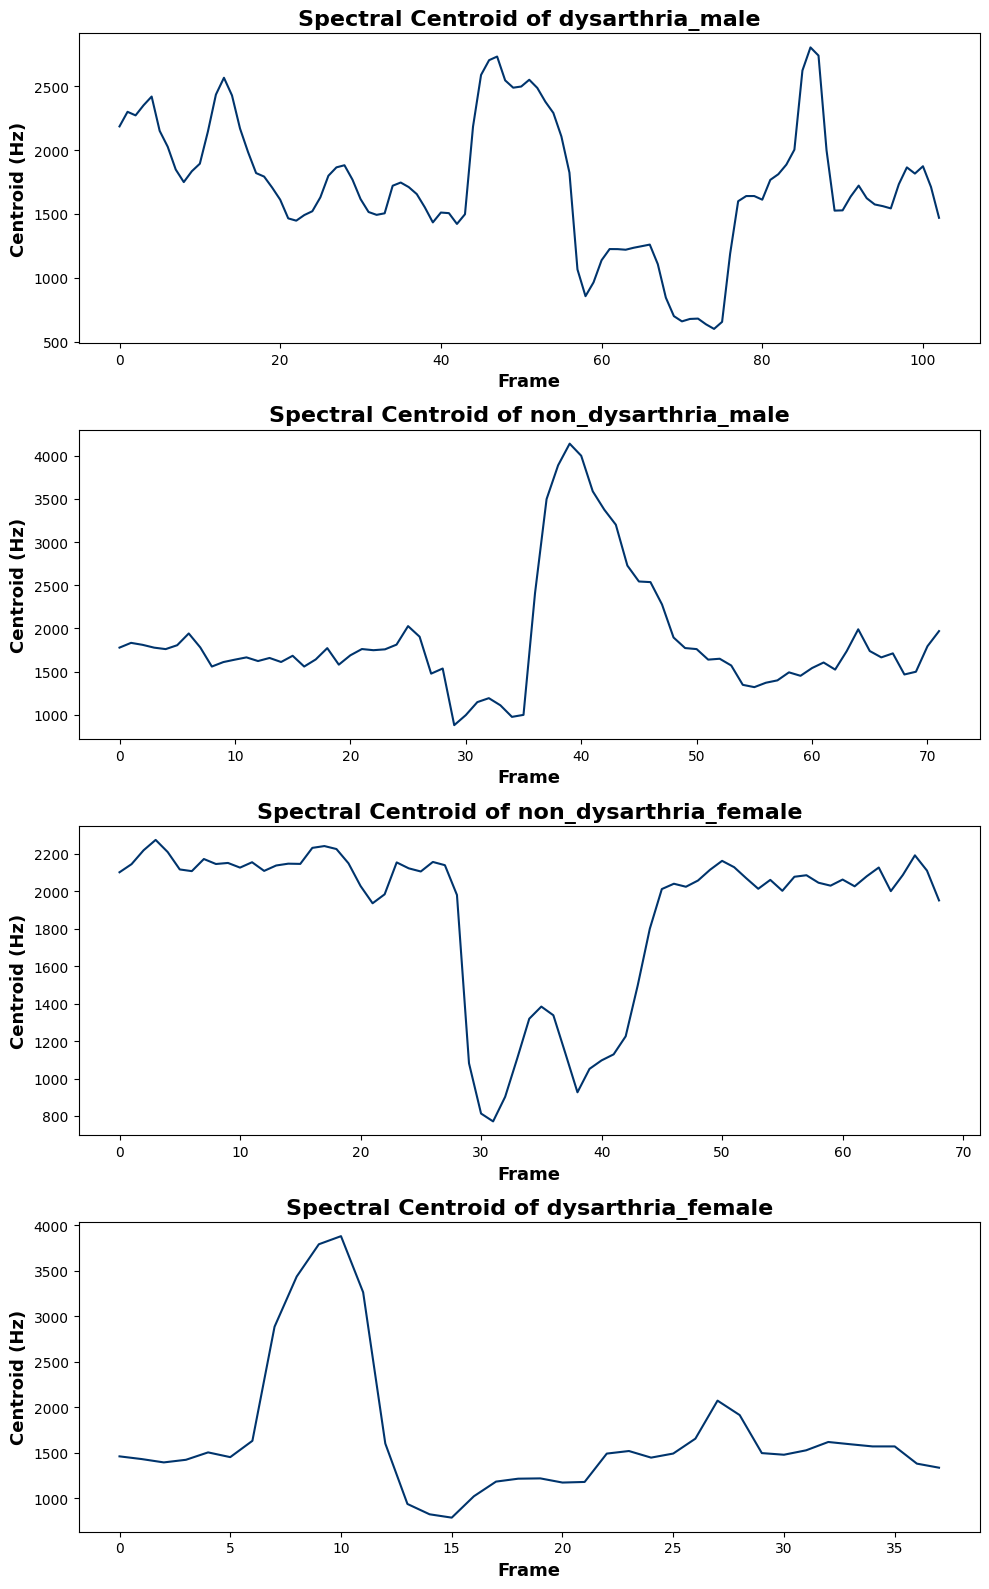

In [ ]:
# Create subplots for spectral centroids from each category
fig, axes = plt.subplots(len(categories), 1, figsize=(10, len(categories) * 4))

# Compute and plot spectral centroid for one audio file from each category
for i, category in enumerate(categories):
    category_path = os.path.join(data_dir, category)
    audio_files = glob.glob(os.path.join(category_path, '*.wav'))

    if audio_files:
        # Load the first audio file in the category
        audio_file = audio_files[0]
        audio_data, sample_rate = librosa.load(audio_file, sr=None)

        # Compute spectral centroid
        spectral_centroid = librosa.feature.spectral_centroid(y=audio_data, sr=sample_rate)[0]

        # Plot the spectral centroid on the corresponding subplot
        axes[i].plot(spectral_centroid, color=colours[3])
        axes[i].set_title(f"Spectral Centroid of {category}", fontsize=16, fontweight='bold')
        axes[i].set_xlabel("Frame", fontsize=13, fontweight='bold')
        axes[i].set_ylabel("Centroid (Hz)", fontsize=13, fontweight='bold')
    else:
        axes[i].set_title(f"No audio files found for {category}")

# Adjust layout
plt.tight_layout()
plt.show()

The charts display spectral centroid values over time for four audio files. The "dysarthria male" plot shows a fluctuating centroid, with a peak around 2500 Hz at frame 48 and a low point around 700 Hz at frame 65. The "non-dysarthria male" plot exhibits a sharp rise to a maximum of approximately 3900 Hz at frame 38, before sharply decreasing. The "non-dysarthria female" plot has a drop from a plateau of 2200 Hz to a low of 900 Hz at frame 35, then rises again. The "dysarthria female" plot shows a sharp increase from 1500 Hz to a peak of 3800 Hz at frame 10, before a sharp decline to 900 Hz at frame 15.

### *Rolloff Frequency*

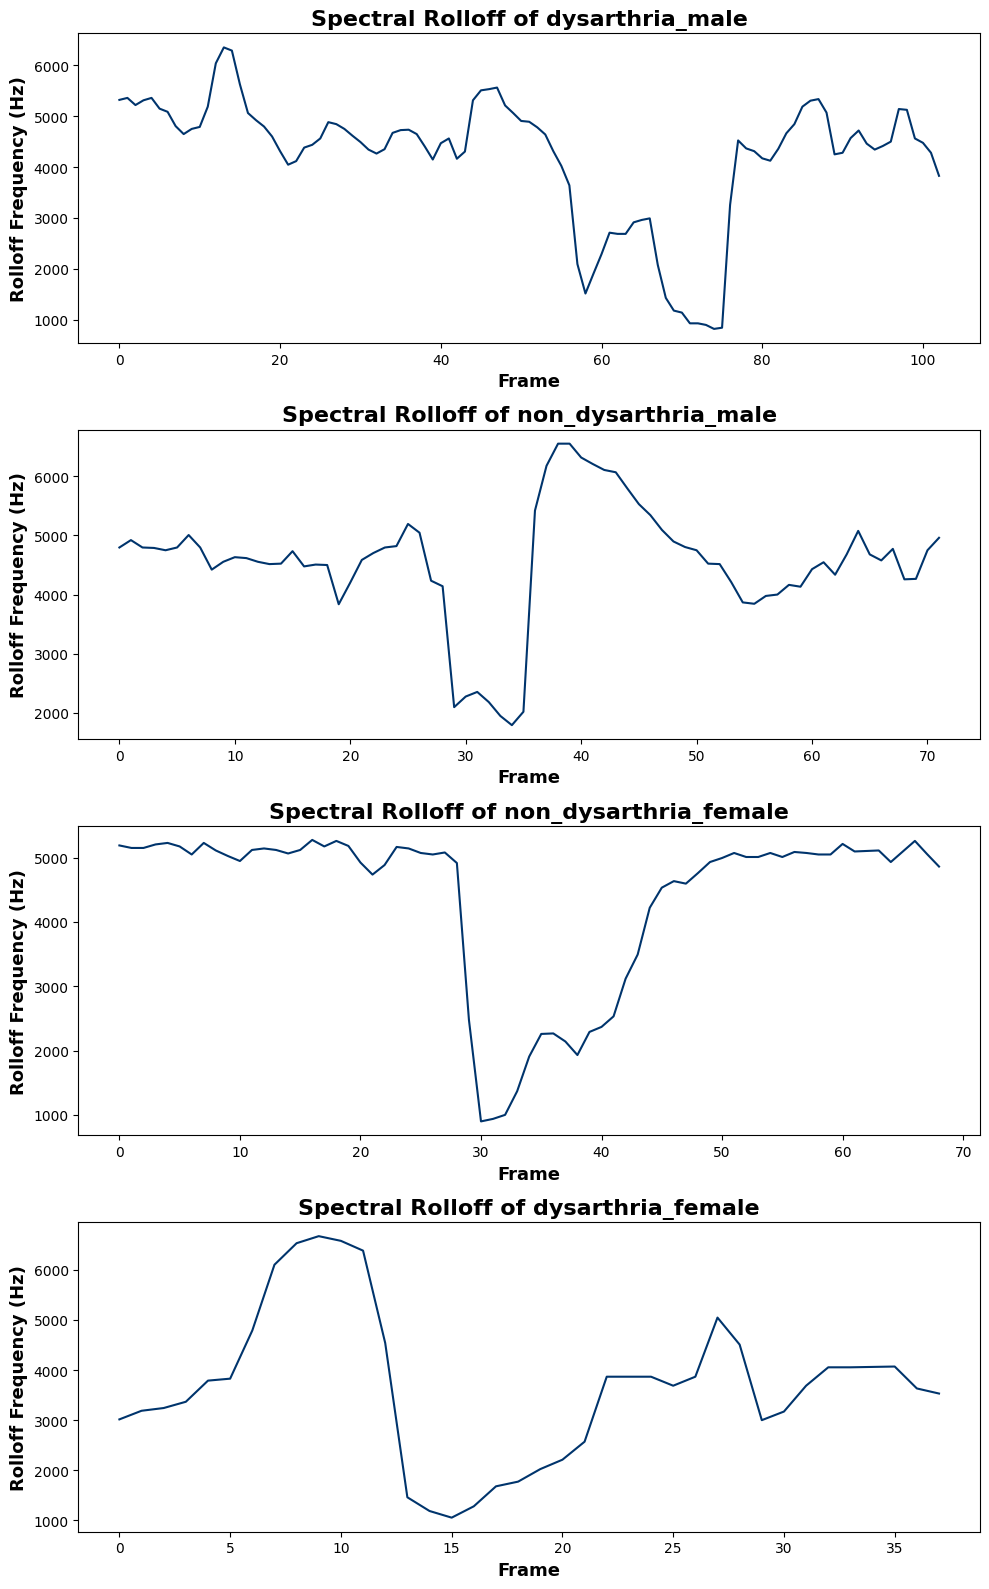

In [ ]:
# Create subplots for spectral rolloff from each category
fig, axes = plt.subplots(len(categories), 1, figsize=(10, len(categories) * 4))

# Compute and plot spectral rolloff for one audio file from each category
for i, category in enumerate(categories):
    category_path = os.path.join(data_dir, category)
    audio_files = glob.glob(os.path.join(category_path, '*.wav'))

    if audio_files:
        # Load the first audio file in the category
        audio_file = audio_files[0]
        audio_data, sample_rate = librosa.load(audio_file, sr=None)

        # Compute spectral rolloff
        spectral_rolloff = librosa.feature.spectral_rolloff(y=audio_data, sr=sample_rate)[0]

        # Plot the spectral rolloff on the corresponding subplot
        axes[i].plot(spectral_rolloff, color=colours[3])
        axes[i].set_title(f"Spectral Rolloff of {category}", fontsize=16, fontweight='bold')
        axes[i].set_xlabel("Frame", fontsize=13, fontweight='bold')
        axes[i].set_ylabel("Rolloff Frequency (Hz)", fontsize=13, fontweight='bold')
    else:
        axes[i].set_title(f"No audio files found for {category}")

# Adjust layout
plt.tight_layout()
plt.show()

The "Spectral Rolloff" plots illustrate the frequency below which 85% of the signal energy is located. The "dysarthria male" plot shows fluctuations, with peaks around 6000 Hz at frame 10 and a low around 1500 Hz at frame 65. The "non-dysarthria male" plot has a significant drop to a low of approximately 2000 Hz at frame 35, preceded and followed by values around 5000 Hz. The "non-dysarthria female" plot displays a sharp decline from a stable 5000 Hz to a low of 1000 Hz at frame 30, followed by a gradual rise. The "dysarthria female" plot shows a sharp increase to a peak of 6500 Hz at frame 10 and then a rapid drop to a low of 1500 Hz at frame 15.

### *MFCCs Plot*

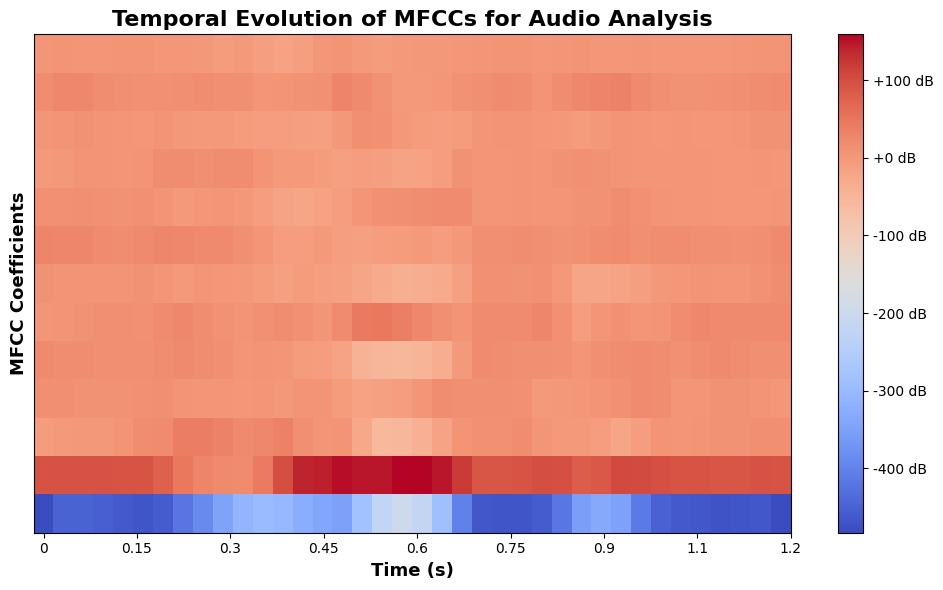

In [ ]:
# Compute MFCCs
mfccs = librosa.feature.mfcc(y=audio_data, sr=sample_rate, n_mfcc=13)

# Plot MFCCs
plt.figure(figsize=(10, 6))

# Display and add Colourbar
librosa.display.specshow(mfccs, sr=sample_rate, x_axis='time')
plt.colorbar(format='%+2.0f dB')

# Add title and Labels
plt.title("Temporal Evolution of MFCCs for Audio Analysis", fontsize=16, fontweight='bold')
plt.xlabel("Time (s)", fontsize=13, fontweight='bold')
plt.ylabel("MFCC Coefficients", fontsize=13, fontweight='bold')

# Show Plot
plt.tight_layout()
plt.show()

The MFCCs plot displays the spectral characteristics of the audio over time. The first coefficient, at the bottom, is consistently high, particularly from 0.45 to 0.75 seconds, where it reaches its maximum red intensity. The higher coefficients show more variation, with some exhibiting higher energy, such as the faint reddish region above -100 dB around 0.6 seconds.

### *Chroma Feature Plot*

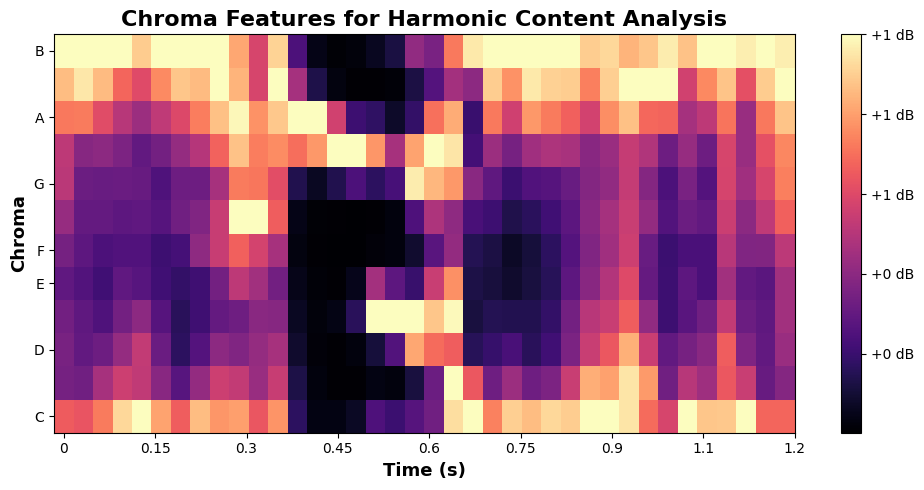

In [ ]:
# Compute Chroma features
chroma_stft = librosa.feature.chroma_stft(y=audio_data, sr=sample_rate)

# Plot Chroma features
plt.figure(figsize=(10, 5))
librosa.display.specshow(chroma_stft, sr=sample_rate, x_axis='time', y_axis='chroma')
plt.colorbar(format='%+2.0f dB')


# Add title and labels
plt.title("Chroma Features for Harmonic Content Analysis", fontsize=16, fontweight='bold')
plt.xlabel("Time (s)", fontsize=13, fontweight='bold')
plt.ylabel("Chroma", fontsize=13, fontweight='bold')

# Show Plot
plt.tight_layout()
plt.show()


The "Chroma Features" chart shows the distribution of pitch classes over time. A strong presence of C and C# is seen at the start, around 0 seconds. From 0.45 to 0.6 seconds, the chart shows a distinct period of low energy, with values below 0 dB. After this, a strong presence of pitches D, E, F, and G becomes apparent.

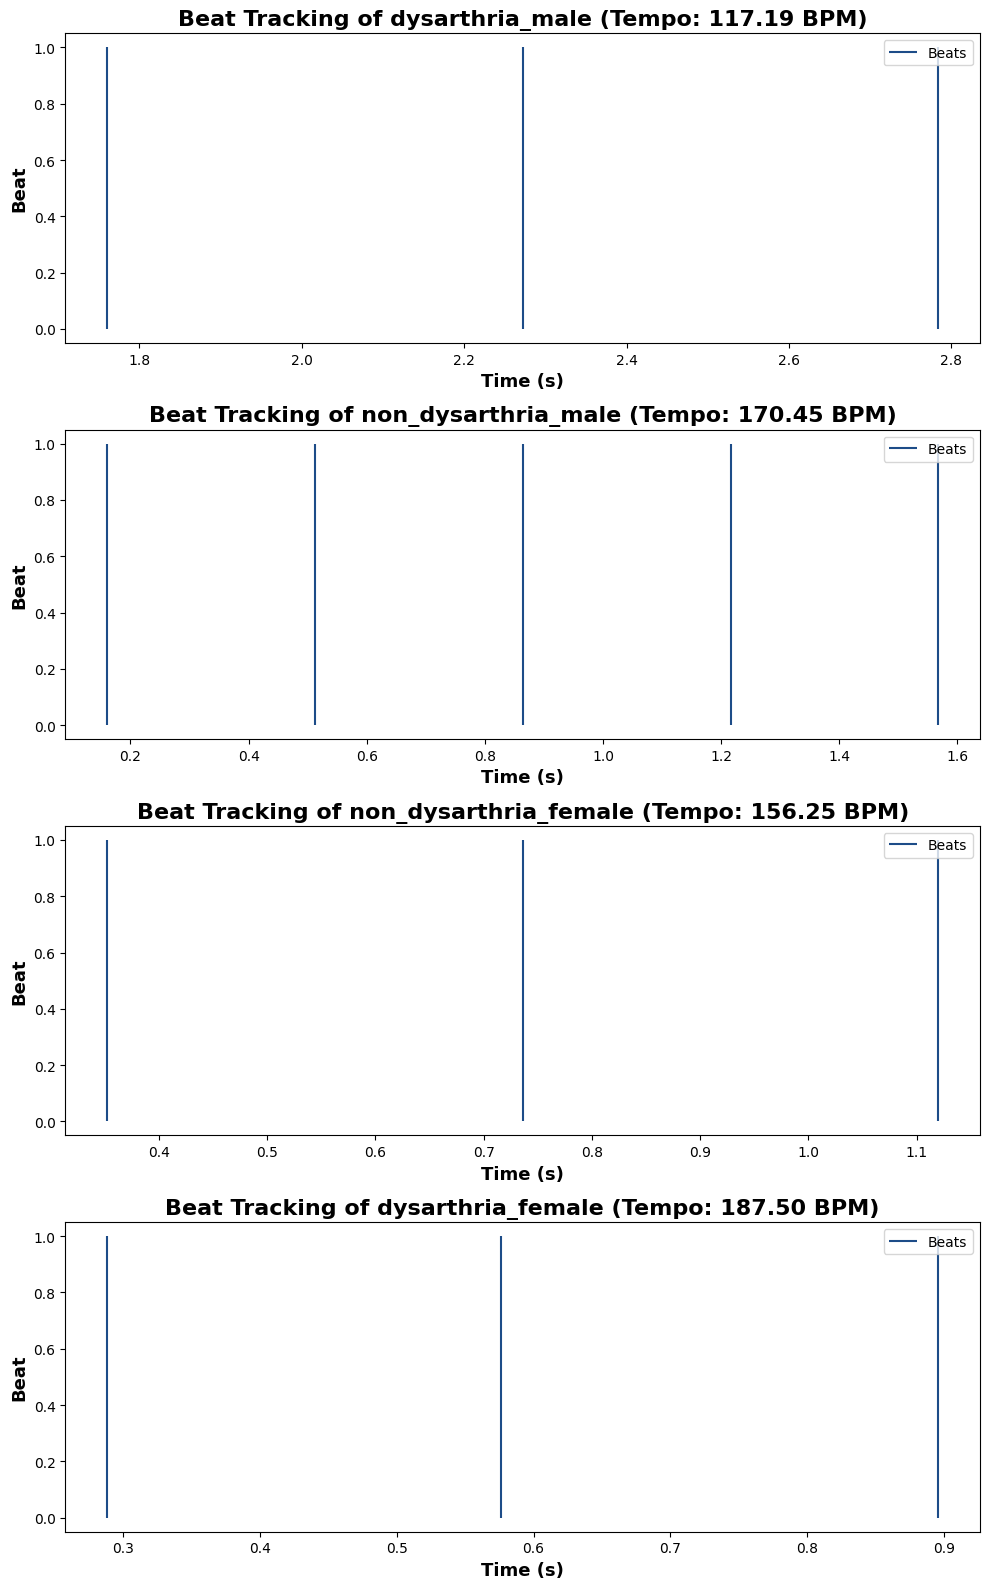

In [ ]:
# Create subplots for tempo and beat tracking from each category
fig, axes = plt.subplots(len(categories), 1, figsize=(10, len(categories) * 4))

# Compute and plot tempo and beat tracking for one audio file from each category
for i, category in enumerate(categories):
    category_path = os.path.join(data_dir, category)
    audio_files = glob.glob(os.path.join(category_path, '*.wav'))

    if audio_files:
        # Load the first audio file in the category
        audio_file = audio_files[0]
        audio_data, sample_rate = librosa.load(audio_file, sr=None)

        # Beat tracking
        tempo, beat_frames = librosa.beat.beat_track(y=audio_data, sr=sample_rate)

        # Ensure tempo is a scalar
        if np.ndim(tempo) > 0:
            tempo = tempo[0]  # Extract the first element if it's an array

        # Convert beat frames to time
        beat_times = librosa.frames_to_time(beat_frames, sr=sample_rate)

        # Plotting
        axes[i].vlines(beat_times, 0, 1, color=colours[2], label='Beats')
        axes[i].set_title(f"Beat Tracking of {category} (Tempo: {tempo:.2f} BPM)", fontsize=16, fontweight='bold')
        axes[i].set_xlabel("Time (s)", fontsize=13, fontweight='bold')
        axes[i].set_ylabel("Beat", fontsize=13, fontweight='bold')
        axes[i].legend()

    else:
        axes[i].set_title(f"No audio files found for {category}")

# Adjust layout
plt.tight_layout()
plt.show()


The charts display the beat tracking and tempo for four audio files. The "dysarthria male" file has a tempo of 117.19 BPM, with beats occurring around 1.7, 2.3, and 2.8 seconds. The "non-dysarthria male" file has a faster tempo of 170.45 BPM, with beats marked at 0.15, 0.5, 0.9, 1.25, and 1.6 seconds. The "non-dysarthria female" file has a tempo of 156.25 BPM, with beats at 0.25, 0.7, and 1.15 seconds. Finally, the "dysarthria female" file has the highest tempo at 187.50 BPM, with beats occurring at 0.3, 0.58, and 0.88 seconds. The intervals between beats vary, but tempos provide an average rate.

### *Pitch Contour Plot*

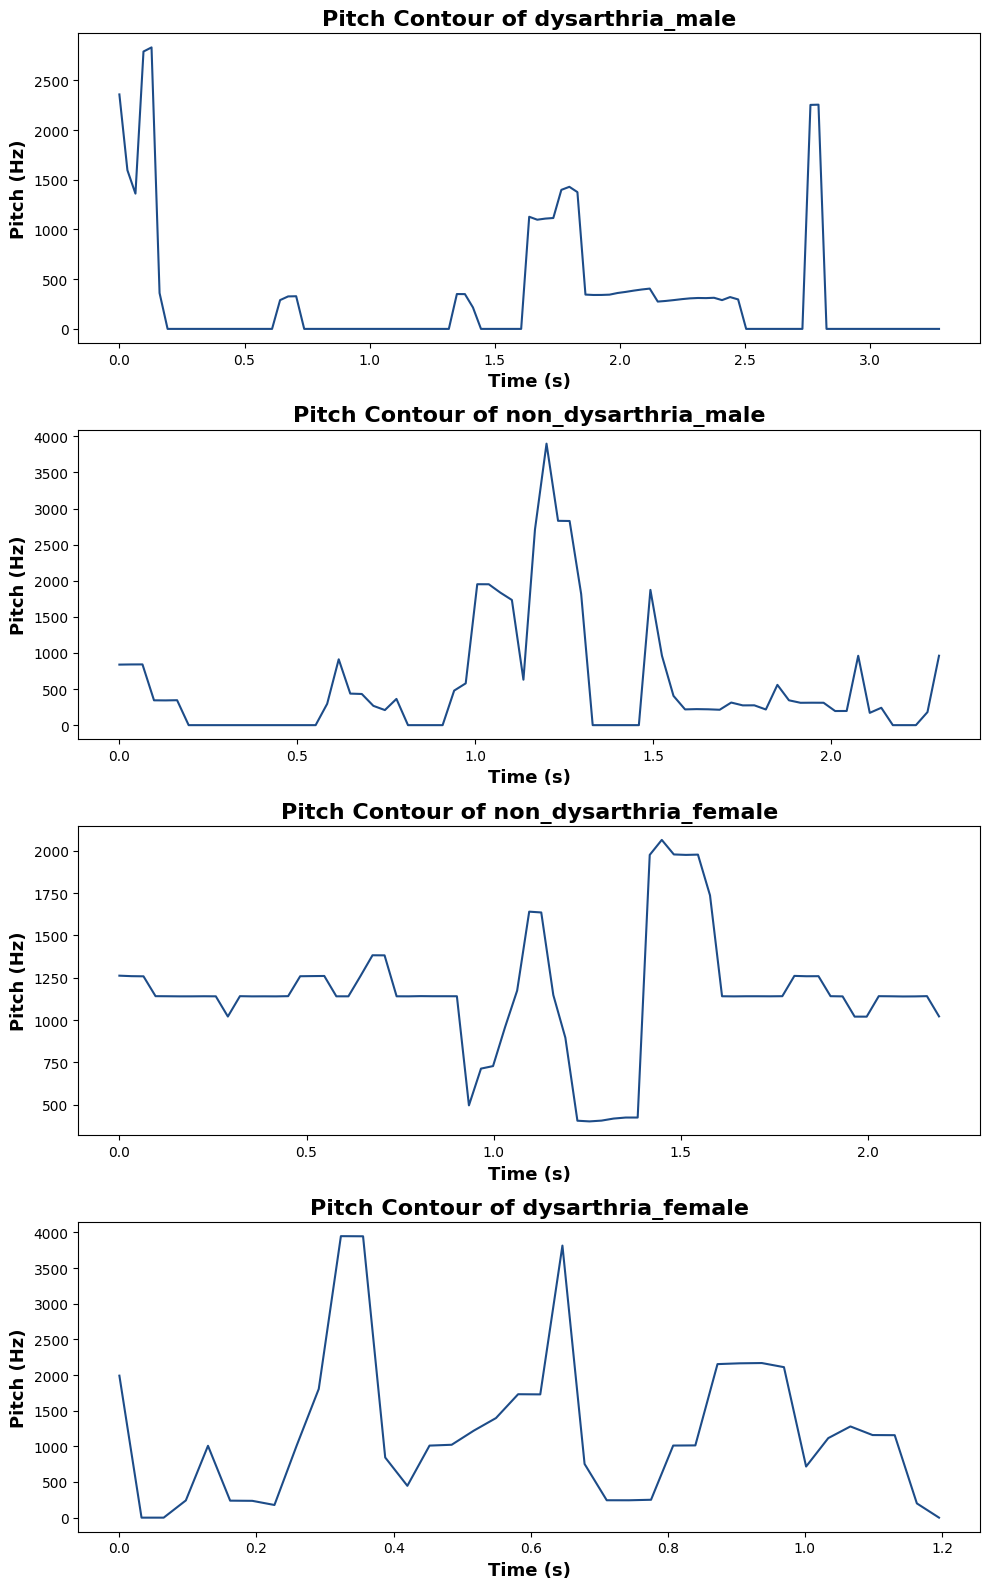

In [ ]:
# Create subplots for pitch contour from each category
fig, axes = plt.subplots(len(categories), 1, figsize=(10, len(categories) * 4))

# Compute and plot pitch contour for one audio file from each category
for i, category in enumerate(categories):
    category_path = os.path.join(data_dir, category)
    audio_files = glob.glob(os.path.join(category_path, '*.wav'))

    if audio_files:
        # Load the first audio file in the category
        audio_file = audio_files[0]
        audio_data, sample_rate = librosa.load(audio_file, sr=None)

        # Compute pitch (frequency) using librosa's piptrack function
        pitches, magnitudes = librosa.piptrack(y=audio_data, sr=sample_rate)

        # Extract the highest magnitude pitch for each frame
        pitch_values = np.max(pitches, axis=0)

        # Plotting
        times = np.linspace(0, len(audio_data) / sample_rate, num=pitch_values.shape[0])
        axes[i].plot(times, pitch_values, color=colours[2])

        # Add Title and Labels
        axes[i].set_title(f"Pitch Contour of {category}", fontsize=16, fontweight='bold')
        axes[i].set_xlabel("Time (s)", fontsize=13, fontweight='bold')
        axes[i].set_ylabel("Pitch (Hz)", fontsize=13, fontweight='bold')

    else:
        axes[i].set_title(f"No audio files found for {category}")

# Adjust layout
plt.tight_layout()
plt.show()


The plots show pitch contours for four audio files. The "dysarthria male" plot starts with a high pitch around 2800 Hz before dropping, with a notable peak of 1500 Hz at 1.7 seconds and a final peak of 2500 Hz at 2.8 seconds. The "non-dysarthria male" plot shows a sharp peak of about 3800 Hz at 1.2 seconds and another peak of 2000 Hz at 1.4 seconds. The "non-dysarthria female" plot exhibits a generally flatter contour with a high pitch around 1700 Hz at 1.25 seconds and another around 1900 Hz at 1.5 seconds. The "dysarthria female" plot has a very high peak around 4000 Hz at 0.35 seconds and a secondary peak around 3500 Hz at 0.65 seconds.

## *Preprocessing*

Normalise Audio scales the waveform between -1 and 1 to maintain balance in amplitude. This avoids distortion while enhancing overall loudness. It ensures consistent energy levels across recordings, which is crucial for reliable processing. Normalisation also preserves the original dynamics of the signal.

Trim Silence eliminates unwanted silent sections at the start or end of recordings. This reduces irrelevant data and sharpens focus on meaningful content. By doing so, it improves clarity in analysis and playback. It also speeds up training by removing unnecessary frames.

AWGN (Additive White Gaussian Noise) adds controlled random noise to an audio signal. This simulates realistic environments where recordings may not be clean. Such augmentation improves model generalisation and robustness during training. It helps prepare the model for noisy real-world inputs.

Pitch Shift modifies the pitch of audio by adjusting semitones while keeping tempo unchanged. This creates tonal variations without affecting duration. It is useful for generating augmented versions of the same sample. Such transformations increase dataset diversity for better training.

MFCCs (Mel-frequency cepstral coefficients) extract spectral features that mimic human auditory perception. They capture timbral and phonetic characteristics critical for analysis. These coefficients are widely used in speech and audio recognition tasks. MFCCs provide a compact, informative representation of sound signals.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import librosa
import soundfile as sf

In [ ]:
# Define your directories and categories
data_dir = '/kaggle/input/dysarthria-detection/torgo_data/'
categories = ['dysarthria_male', 'non_dysarthria_male', 'non_dysarthria_female', 'dysarthria_female']


In [ ]:
for category in categories:
    category_path = os.path.join(data_dir, category)
    audio_files = glob.glob(os.path.join(category_path, '*.wav'))

    print(f"Found {len(audio_files)} audio files in category: {category}")


Found 500 audio files in category: dysarthria_male
Found 500 audio files in category: non_dysarthria_male
Found 500 audio files in category: non_dysarthria_female
Found 500 audio files in category: dysarthria_female


In [ ]:
# For Agumentation
def add_awgn(audio_data, noise_level=0.005):
  noise = np.random.normal(0, noise_level, audio_data.shape)
  return audio_data + noise

In [ ]:
def preprocess_audio(file_path):
  # add try and except block for handling errors
  try:
    # Load audio file
    audio_data, sample_rate = librosa.load(file_path, sr=None)

    # Check audio length with adjusting the minimum threshold as 1024
    if len(audio_data) < 1024:
      print(f"Skipping {file_path} due to insufficient length.")
      return None, None, None, None, None

    # 1. Normalise the audio data
    audio_data = audio_data / np.max(np.abs(audio_data))

    # 2. Trim silence
    audio_data, _ = librosa.effects.trim(audio_data)

    # 3. Data augmentation: Add AWGN
    audio_data = add_awgn(audio_data)

    # 4. Data augmentation: Pitch shifting
    pitch_shifted_audio = librosa.effects.pitch_shift(audio_data, sr=sample_rate, n_steps=2)  # Shift up by 2 semitones

    # 5. Resampling (to 22.05 kHz)
    target_sr = 22050
    audio_data = librosa.resample(audio_data, orig_sr=sample_rate, target_sr=target_sr)
    pitch_shifted_audio = librosa.resample(pitch_shifted_audio, orig_sr=sample_rate, target_sr=target_sr)

    # 6. Feature Extraction: MFCCs
    mfccs = librosa.feature.mfcc(y=audio_data, sr=target_sr, n_mfcc=13)
    pitch_shifted_mfccs = librosa.feature.mfcc(y=pitch_shifted_audio, sr=target_sr, n_mfcc=13)

    return audio_data, pitch_shifted_audio, mfccs, pitch_shifted_mfccs, target_sr

  # Check the Errors for Librosa
  except librosa.util.exceptions.LibrosaError as e:
    print(f"Librosa error processing {file_path}: {e}")
    with open("error_log.txt", "a") as error_log:
      error_log.write(f"Librosa error processing {file_path}: {e}\n")
    return None, None, None, None, None

  # Check General Errors
  except Exception as e:
        print(f"General error processing {file_path}: {e}")
        with open("error_log.txt", "a") as error_log:
            error_log.write(f"Error processing {file_path}: {e}\n")
        return None, None, None, None, None

The above function:

Load Audio loads the audio file into memory and retrieves both waveform data and its corresponding sample rate. This provides the raw input for further processing.

Check Length ensures the audio clip is sufficiently long for analysis or training. If too short, it is skipped to maintain quality.

Normalise Audio scales waveform values within the range of -1 to 1. This enhances volume consistency without introducing distortion.

Trim Silence removes unnecessary leading and trailing silence from the audio. This keeps the focus on meaningful sound content only.

Add AWGN introduces controlled Gaussian noise to simulate real-world audio conditions. This increases data diversity and improves model robustness.

Pitch Shift modifies the pitch upward by 2 semitones while preserving playback speed. This generates tonal variation for augmentation.

Resample changes the audio sample rate to 22.05 kHz. This standardises data and reduces computational requirements during processing.

Extract MFCCs calculates mel-frequency cepstral coefficients from the audio. These compact features capture essential characteristics for recognition or classification tasks.

In [ ]:
processed_data = []

In [ ]:
# Loop through categories and preprocess all audio files in each category
for category in categories:
    category_path = os.path.join(data_dir, category)
    audio_files = glob.glob(os.path.join(category_path, '*.wav'))

    # Debuging
    print(f"Found {len(audio_files)} audio files in category: {category}")

    for audio_file in audio_files:
        # Preprocess the audio file
        audio_data, pitch_shifted_audio, mfccs, pitch_shifted_mfccs, sample_rate = preprocess_audio(audio_file)

        # Only proceed if MFCCs were extracted
        if mfccs is not None:
            # Define the class based on the category
            audio_class = 1 if "dysarthria" in category else 0

            # Store the MFCCs and other data in a dictionary and Loop over time frames
            for i in range(mfccs.shape[1]):
                processed_data.append({
                    'file_name': os.path.basename(audio_file),
                    'category': category,
                    'class': audio_class,
                    'mfcc_1': mfccs[0, i],
                    'mfcc_2': mfccs[1, i],
                    'mfcc_3': mfccs[2, i],
                    'mfcc_4': mfccs[3, i],
                    'mfcc_5': mfccs[4, i],
                    'mfcc_6': mfccs[5, i],
                    'mfcc_7': mfccs[6, i],
                    'mfcc_8': mfccs[7, i],
                    'mfcc_9': mfccs[8, i],
                    'mfcc_10': mfccs[9, i],
                    'mfcc_11': mfccs[10, i],
                    'mfcc_12': mfccs[11, i],
                    'mfcc_13': mfccs[12, i]
                })

# Create DataFrame and save the processed data
preprocessed_df = pd.DataFrame(processed_data)
preprocessed_df.to_csv('/kaggle/working/preprocessed_audio_data.csv', index=False)
print("Preprocessed data saved to /kaggle/working/preprocessed_audio_data.csv.")

Found 500 audio files in category: dysarthria_male
Skipping /kaggle/input/dysarthria-detection/torgo_data/dysarthria_male/M05_Session2_0346.wav due to insufficient length.
Skipping /kaggle/input/dysarthria-detection/torgo_data/dysarthria_male/M05_Session2_0339.wav due to insufficient length.
Skipping /kaggle/input/dysarthria-detection/torgo_data/dysarthria_male/M05_Session2_0352.wav due to insufficient length.
Skipping /kaggle/input/dysarthria-detection/torgo_data/dysarthria_male/M05_Session2_0356.wav due to insufficient length.
Skipping /kaggle/input/dysarthria-detection/torgo_data/dysarthria_male/M05_Session2_0351.wav due to insufficient length.
Skipping /kaggle/input/dysarthria-detection/torgo_data/dysarthria_male/M05_Session2_0360.wav due to insufficient length.
Skipping /kaggle/input/dysarthria-detection/torgo_data/dysarthria_male/M05_Session2_0303.wav due to insufficient length.
Skipping /kaggle/input/dysarthria-detection/torgo_data/dysarthria_male/M05_Session2_0344.wav due to in

In [ ]:
# Verify if the data is preprocessed
preprocessed_df.head()

,file_name,category,class,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13
0,M05_Session2_0075.wav,dysarthria_male,1,-334.079778,36.245739,-4.106461,37.019744,-7.767963,19.456465,-8.514346,6.845076,-4.437459,-4.621091,6.163960,-0.110295,-1.554318
1,M05_Session2_0075.wav,dysarthria_male,1,-311.042024,31.917079,-15.728821,33.454589,-12.967488,23.148052,-7.333479,13.103602,-4.066070,0.811768,2.795396,-1.168773,2.208573
2,M05_Session2_0075.wav,dysarthria_male,1,-312.867298,32.459481,-19.867466,26.423866,-14.418718,25.054642,-2.575685,15.033432,-4.156649,3.412154,1.900845,-1.864838,8.107684
3,M05_Session2_0075.wav,dysarthria_male,1,-309.056822,36.387499,-21.017761,26.179300,-15.764963,22.452870,-2.295910,15.402363,-2.285760,0.518506,0.116745,2.357544,11.961135
4,M05_Session2_0075.wav,dysarthria_male,1,-314.366079,33.845809,-18.603178,27.576138,-13.162823,21.657549,-6.877514,15.198977,0.910417,4.933688,0.315909,-1.211013,10.120619


In [ ]:
preprocessed_df['category'].unique()

array(['dysarthria_male', 'non_dysarthria_male', 'non_dysarthria_female',
       'dysarthria_female'], dtype=object)

In [ ]:
preprocessed_df['class'].unique()

array([1])

In [ ]:
# Drop unwanted column
preprocessed_df = preprocessed_df.drop(['file_name', 'class'], axis=1)

In [ ]:
# Verify if the data is preprocessed
preprocessed_df.head()

,category,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13
0,dysarthria_male,-334.079778,36.245739,-4.106461,37.019744,-7.767963,19.456465,-8.514346,6.845076,-4.437459,-4.621091,6.163960,-0.110295,-1.554318
1,dysarthria_male,-311.042024,31.917079,-15.728821,33.454589,-12.967488,23.148052,-7.333479,13.103602,-4.066070,0.811768,2.795396,-1.168773,2.208573
2,dysarthria_male,-312.867298,32.459481,-19.867466,26.423866,-14.418718,25.054642,-2.575685,15.033432,-4.156649,3.412154,1.900845,-1.864838,8.107684
3,dysarthria_male,-309.056822,36.387499,-21.017761,26.179300,-15.764963,22.452870,-2.295910,15.402363,-2.285760,0.518506,0.116745,2.357544,11.961135
4,dysarthria_male,-314.366079,33.845809,-18.603178,27.576138,-13.162823,21.657549,-6.877514,15.198977,0.910417,4.933688,0.315909,-1.211013,10.120619


In [ ]:
# Shuffle the data for training purpose
preprocessed_df = preprocessed_df.sample(frac=1).reset_index(drop=True)

In [ ]:
# Verify it
preprocessed_df.head()

,category,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13
0,non_dysarthria_female,-278.717189,87.149509,-1.669686,40.519889,-11.923277,35.019064,0.383239,23.623029,-0.400209,10.079712,4.484794,-4.163902,11.048600
1,dysarthria_female,-258.241989,69.572976,-3.626566,30.767860,-10.848654,28.464858,1.727248,18.408506,6.147524,17.374348,10.666564,-0.833520,6.767434
2,non_dysarthria_female,-292.939346,48.763264,-12.187439,34.004716,-10.320759,30.852692,-2.175848,21.929013,7.377618,14.678025,8.722394,2.523938,12.032468
3,dysarthria_female,-292.089358,59.202672,-8.560481,41.506382,-12.865461,28.490836,-1.053366,22.167424,0.445451,11.735954,6.390913,2.248285,12.340604
4,dysarthria_female,-150.574333,179.226956,-28.207598,-19.625478,-60.599134,17.415207,-23.503264,4.947159,-6.227672,1.224714,-3.635603,-1.172954,21.603241


### *Mapping*

In [ ]:
# Define the mapping for the categories
category_mapping = {
    'dysarthria_male': 1,
    'dysarthria_female': 1,
    'non_dysarthria_male': 0,
    'non_dysarthria_female': 0
}

# Apply the mapping to the 'category' column and create a 'class' column
preprocessed_df['class'] = preprocessed_df['category'].map(category_mapping)

This helps in creating new class where dysarthria class is 1 and non-dysarthria is 0.

In [ ]:
# Check if the mapping was applied correctly
print(preprocessed_df[['category', 'class']].head())

                category  class
0  non_dysarthria_female      0
1      dysarthria_female      1
2  non_dysarthria_female      0
3      dysarthria_female      1
4      dysarthria_female      1


### *Scaling*

Scaling transforms audio features by subtracting the mean and dividing by the standard deviation. This process results in a distribution with a mean of 0 and a standard deviation of 1.

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
# Separate the independent and dependent column
X = preprocessed_df.drop(['category', 'class'], axis=1)
y = preprocessed_df['class']

In [ ]:
# Initialise the StandardScaler
scaler = StandardScaler()

In [ ]:
# Applying Scaling
X_mfccs = scaler.fit_transform(X)

In [ ]:
import joblib

# Save the fitted scaler to a file
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [ ]:
# Verify it
X_mfccs

array([[-0.71282286, -0.12192232,  0.75078012, ...,  0.21566138,
        -0.11771934,  0.48052076],
       [-0.43866069, -0.5700204 ,  0.6572627 , ...,  0.96799607,
         0.29108871, -0.09041632],
       [-0.903257  , -1.10054551,  0.24814684, ...,  0.73138641,
         0.70322035,  0.61172959],
       ...,
       [ 0.70519425,  1.0886002 ,  0.09594374, ..., -1.21381289,
        -1.81148275, -0.98458398],
       [ 0.52827259,  0.62738729, -0.12625586, ...,  0.30124007,
        -0.26404579,  0.5913915 ],
       [ 1.28672976,  1.5716922 ,  0.07978941, ...,  0.6541264 ,
         1.94371556, -0.19396978]])

## *Model Building*

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Conv1D, MaxPooling1D, BatchNormalization, Dropout, Flatten, LSTM, Bidirectional, Reshape, Add,  Activation, GlobalAveragePooling1D, Layer
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, log_loss

In [ ]:
# Split data into 80% train and 20% test then split 20% into validation
X_train, X_test, y_train, y_test = train_test_split(X_mfccs, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, random_state=42, stratify=y_train)

# Check the shape of the datasets
print(f"Training set: {X_train.shape}, Validation set: {X_val.shape}, Test set: {X_test.shape}")

Training set: (189141, 13), Validation set: (27021, 13), Test set: (54041, 13)


In [ ]:
# Reshape input data to 3D (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

### *Dys-CNN Model*

A Conv1D model applies one-dimensional convolutional layers to sequential data such as audio or text. It captures local temporal patterns by sliding filters across the sequence. This enables efficient feature extraction while reducing input dimensionality. Conv1D models are widely used for speech, audio, and time-series classification tasks.

In [ ]:
# Define the CNN-1D model
def base_model():
    model = Sequential()

    # First convolutional block: feature extraction from input sequence
    model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(BatchNormalization())

    # Second convolutional block: deeper feature extraction
    model.add(Conv1D(128, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(BatchNormalization())

    # Fully connected layers: classification based on extracted features
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))  # Binary classification

    # Compile the model with appropriate loss and optimiser
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

#### *KFold Cross Validation*

 K-fold cross-validation, the data set is divided into a number of K-folds and used to assess the model's ability as new data become available.

In [ ]:
# Define KFold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [ ]:
# Variables to store results
fold_no = 1
accuracy_per_fold = []
loss_per_fold = []

In [ ]:
# Loop over each fold
for train_index, val_index in kf.split(X_mfccs):

    # Split the data
    X_train, X_val = X_mfccs[train_index], X_mfccs[val_index]
    y_train, y_val = y[train_index], y[val_index]

    # Reshape the data for Conv1D
    X_train_reshaped = X_train[..., np.newaxis]
    X_val_reshaped = X_val[..., np.newaxis]

    # Build the model
    model = base_model()

    # Train the model
    history = model.fit(X_train_reshaped, y_train,
                        validation_data=(X_val_reshaped, y_val),
                        epochs=30,
                        batch_size=128,
                        callbacks=[early_stopping],
                        verbose=1)

    # Evaluate the model
    scores = model.evaluate(X_val_reshaped, y_val, verbose=0)
    print(f"Score for fold {fold_no}: {model.metrics_names[0]} = {scores[0]}; {model.metrics_names[1]} = {scores[1]*100}%")

    accuracy_per_fold.append(scores[1] * 100)
    loss_per_fold.append(scores[0])

    fold_no += 1

Epoch 1/30


I0000 00:00:1757569752.860825     112 service.cc:148] XLA service 0x78bcd8007a90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757569752.862007     112 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1757569752.862028     112 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1757569753.319555     112 cuda_dnn.cc:529] Loaded cuDNN version 90300


  64/1689 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6821 - loss: 0.6115

I0000 00:00:1757569756.731419     112 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1689/1689 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.7805 - loss: 0.4563 - val_accuracy: 0.8247 - val_loss: 0.3812
Epoch 2/30
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8259 - loss: 0.3806 - val_accuracy: 0.8388 - val_loss: 0.3507
Epoch 3/30
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8355 - loss: 0.3638 - val_accuracy: 0.8461 - val_loss: 0.3436
Epoch 4/30
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8400 - loss: 0.3557 - val_accuracy: 0.8493 - val_loss: 0.3347
Epoch 5/30
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8438 - loss: 0.3467 - val_accuracy: 0.8458 - val_loss: 0.3407
Epoch 6/30
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8468 - loss: 0.3419 - val_accuracy: 0.8484 - val_loss: 0.3321
Epoch 7/30
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8507 - loss: 0.3357 - val_accuracy: 0.8536 - val_loss: 0.3243
Epoch 8/30
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8503 - loss: 0.3344 - val_accura

In [ ]:
# Print overall results
print('------------------------------------------------------------------------')
print('Score per fold')
for i in range(0, len(accuracy_per_fold)):
    print(f'> Fold {i+1} - Loss: {loss_per_fold[i]} - Accuracy: {accuracy_per_fold[i]}%')
print('------------------------------------------------------------------------')
print(f'Average accuracy for all folds: {np.mean(accuracy_per_fold)}% (+- {np.std(accuracy_per_fold)})')
print(f'Average loss for all folds: {np.mean(loss_per_fold)}')
print('------------------------------------------------------------------------')


------------------------------------------------------------------------
Score per fold
> Fold 1 - Loss: 0.30059123039245605 - Accuracy: 86.4473283290863%
> Fold 2 - Loss: 0.30837711691856384 - Accuracy: 86.3918125629425%
> Fold 3 - Loss: 0.29674407839775085 - Accuracy: 86.73229813575745%
> Fold 4 - Loss: 0.3169342875480652 - Accuracy: 85.97150444984436%
> Fold 5 - Loss: 0.30179864168167114 - Accuracy: 86.61361932754517%
------------------------------------------------------------------------
Average accuracy for all folds: 86.43131256103516% (+- 0.2596414169960861)
Average loss for all folds: 0.3048890709877014
------------------------------------------------------------------------


The model achieved an average accuracy of 86.43% with a variability of plus minus 0.2596414169960861 and maintained an average loss of 0.305 indicating strong performance.


#### *Train and Evaluate Model*

In [ ]:
# Build the model
dys_cnn_model = base_model()

In [ ]:
# Train the model
dys_cnn_history = dys_cnn_model.fit(X_train, y_train, epochs=25, batch_size=32,validation_data=(X_val, y_val), verbose=1)

Epoch 1/25
6756/6756 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.7749 - loss: 0.4675 - val_accuracy: 0.8214 - val_loss: 0.3885
Epoch 2/25
6756/6756 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.8192 - loss: 0.3931 - val_accuracy: 0.8408 - val_loss: 0.3540
Epoch 3/25
6756/6756 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.8305 - loss: 0.3747 - val_accuracy: 0.8394 - val_loss: 0.3536
Epoch 4/25
6756/6756 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.8350 - loss: 0.3669 - val_accuracy: 0.8388 - val_loss: 0.3554
Epoch 5/25
6756/6756 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.8385 - loss: 0.3600 - val_accuracy: 0.8508 - val_loss: 0.3326
Epoch 6/25
6756/6756 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.8401 - loss: 0.3549 - val_accuracy: 0.8510 - val_loss: 0.3304
Epoch 7/25
6756/6756 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.8447 - loss: 0.3477 - val_accuracy: 0.8506 - val_loss: 0.3316
Epoch 8/25
6756/6756 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.8452 - loss: 0

In [ ]:
# Predictions on the test set
dys_cnn_y_pred_prob = dys_cnn_model.predict(X_test)
dys_cnn_y_pred = np.round(dys_cnn_y_pred_prob).astype(int)

1689/1689 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


In [ ]:
# lassification report
dys_cnn_report = classification_report(y_test, dys_cnn_y_pred, target_names=['Non-Dysarthria', 'Dysarthria'], output_dict=True)

In [ ]:
# Extract metrics
dys_cnn_accuracy = accuracy_score(y_test, dys_cnn_y_pred)
dys_cnn_precision = dys_cnn_report['Dysarthria']['precision']
dys_cnn_recall = dys_cnn_report['Dysarthria']['recall']
dys_cnn_f1 = dys_cnn_report['Dysarthria']['f1-score']
dys_cnn_log_loss = log_loss(y_test, dys_cnn_y_pred_prob)

In [ ]:
# Print results
print("Dysarthria CNN Model Results")
print(f"Accuracy: {dys_cnn_accuracy:.4f}")
print(f"Precision: {dys_cnn_precision:.4f}")
print(f"Recall: {dys_cnn_recall:.4f}")
print(f"F1 Score: {dys_cnn_f1:.4f}")
print(f"Log Loss: {dys_cnn_log_loss:.4f}")

Dysarthria CNN Model Results
Accuracy: 0.8613
Precision: 0.8925
Recall: 0.8600
F1 Score: 0.8759
Log Loss: 0.3082


The Dysarthria CNN model achieved accuracy of 0.8613, precision of 0.8925, recall of 0.8600, and F1 score of 0.8759, with log loss recorded at 0.3082, reflecting balanced predictive performance and reliable classification ability.


In [ ]:
# Print Report
print(classification_report(y_test, dys_cnn_y_pred, target_names=['Non-Dysarthria', 'Dysarthria']))

                precision    recall  f1-score   support

Non-Dysarthria       0.82      0.86      0.84     23271
    Dysarthria       0.89      0.86      0.88     30770

      accuracy                           0.86     54041
     macro avg       0.86      0.86      0.86     54041
  weighted avg       0.86      0.86      0.86     54041



In [ ]:
# Define the colormap
cmap = ['#5e80c2', '#4065a5', '#1d4c88', '#00346c']

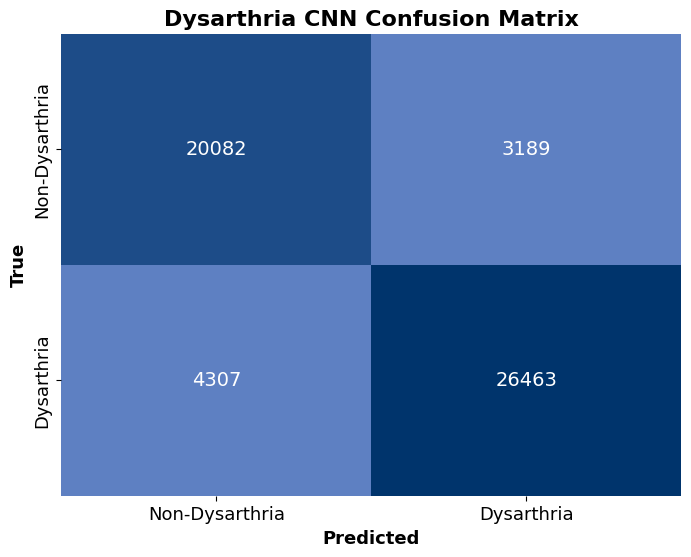

In [ ]:
# Confusion Matrix
dys_cnn_conf_matrix = confusion_matrix(y_test, dys_cnn_y_pred)

plt.figure(figsize=(8, 6))

# Make a HeatMap
sns.heatmap(dys_cnn_conf_matrix, annot=True, fmt='d', cmap=sns.color_palette(cmap), cbar=False,
            xticklabels=['Non-Dysarthria', 'Dysarthria'], yticklabels=['Non-Dysarthria', 'Dysarthria'], annot_kws={"size": 14})

# Adding title and labels
plt.title('Dysarthria CNN Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted', fontsize=13, fontweight='bold')
plt.ylabel('True', fontsize=13, fontweight='bold')

# Adding ticks
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# Show Plot
plt.show()

The Dysarthria CNN Confusion Matrix shows the model's performance. The model correctly identified 20082 non-dysarthria cases and 26463 dysarthria cases. There were 3189 false positives, where non-dysarthria was incorrectly predicted as dysarthria, and 4307 false negatives, where dysarthria was incorrectly predicted as non-dysarthria.

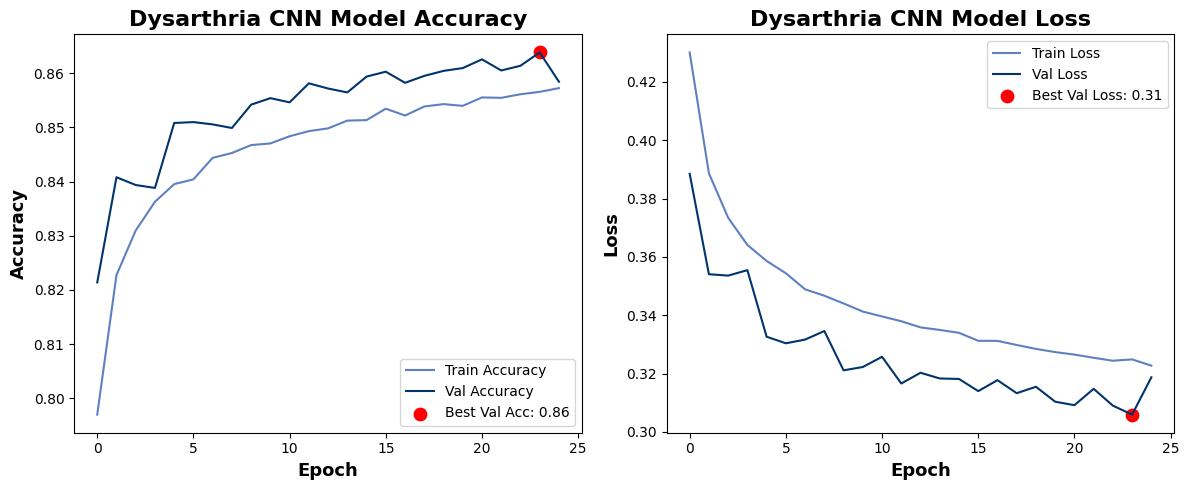

In [ ]:
# Plot training history
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(dys_cnn_history.history['accuracy'], label='Train Accuracy', color=cmap[0])
plt.plot(dys_cnn_history.history['val_accuracy'], label='Val Accuracy', color=cmap[3])

# Find best val accuracy
best_acc_epoch = np.argmax(dys_cnn_history.history['val_accuracy'])
best_acc = dys_cnn_history.history['val_accuracy'][best_acc_epoch]

# Mark best point
plt.scatter(best_acc_epoch, best_acc, color='red', s=80, label=f'Best Val Acc: {best_acc:.2f}')

# Add Title and Labels
plt.title('Dysarthria CNN Model Accuracy', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy', fontsize=13, fontweight='bold')
plt.xlabel('Epoch', fontsize=13, fontweight='bold')
plt.legend(loc='best')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(dys_cnn_history.history['loss'], label='Train Loss', color=cmap[0])
plt.plot(dys_cnn_history.history['val_loss'], label='Val Loss', color=cmap[3])

# Find best (min) val loss
best_loss_epoch = np.argmin(dys_cnn_history.history['val_loss'])
best_loss = dys_cnn_history.history['val_loss'][best_loss_epoch]

# Mark best point
plt.scatter(best_loss_epoch, best_loss, color='red', s=80, label=f'Best Val Loss: {best_loss:.2f}')

# Add Title and Labels
plt.title('Dysarthria CNN Model Loss', fontsize=16, fontweight='bold')
plt.ylabel('Loss', fontsize=13, fontweight='bold')
plt.xlabel('Epoch', fontsize=13, fontweight='bold')
plt.legend(loc='best')

# Show plot
plt.tight_layout()
plt.show()


The plots show the training progress of the Dysarthria CNN model. The accuracy plot shows both training and validation accuracy steadily increasing, with the best validation accuracy reaching 0.86. The loss plot shows both training and validation loss decreasing over epochs, with the best validation loss reaching 0.31, indicating that the model is learning effectively and not overfitting.

### *Dys-CNNBiLSTM*

A CNN-BiLSTM model combines convolutional layers with bidirectional LSTMs for sequential data analysis. CNN extracts local spatial or temporal features effectively. BiLSTM captures both past and future dependencies. Together, they enhance feature representation for complex classification tasks.

In [ ]:
# Define the CNN-1D base model as a function
def cnn_base_model(input_shape):
    inputs = Input(shape=input_shape)

    # First convolutional layer
    x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = MaxPooling1D(pool_size=2)(x)
    x = BatchNormalization()(x)

    # Second convolutional layer
    x = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = BatchNormalization()(x)

    # Residual connection
    residual = Conv1D(128, kernel_size=1, padding='same')(x)  # Used to ensure it matches shape
    x = Add()([x, residual])
    x = Activation('relu')(x)

    # Keep the output shape suitable for LSTM that is batch_size, time_steps, features.
    return Model(inputs, x)

In [ ]:
# Define the  CNN-BiLSTM model using the cnn_base_model
def dys_cnn_bilstm_model(input_shape):
    model = Sequential()

    # Adding CNN base model (feature extraction part)
    cnn_model = cnn_base_model(input_shape)
    model.add(cnn_model)

    # Calculate the output shape of the CNN model
    cnn_output_shape = cnn_model.output_shape[1:]
    time_steps = cnn_output_shape[0]
    features = cnn_output_shape[1]

    # Reshape the output of the CNN to match the input shape required by LSTM
    model.add(Reshape((time_steps, features)))

    # Adding BiLSTM layers
    model.add(Bidirectional(LSTM(64, return_sequences=True)))
    model.add(Dropout(0.5))

    model.add(Bidirectional(LSTM(64)))
    model.add(Dropout(0.5))

    # Dense Layers for classification
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))

    # Output Layer (Binary Classification)
    model.add(Dense(1, activation='sigmoid'))

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    return model

#### *KFold Cross Validation*

In [ ]:
# K-Fold Cross Validation
fold_no = 1
for train_index, val_index in kf.split(X_mfccs):

    # Split the data
    X_train, X_val = X_mfccs[train_index], X_mfccs[val_index]
    y_train, y_val = y[train_index], y[val_index]

    # Reshape the data for Conv1D
    X_train_reshaped = X_train[..., np.newaxis]
    X_val_reshaped = X_val[..., np.newaxis]

    # Build the model
    input_shape = (X_train_reshaped.shape[1], 1)
    hybrid_model = dys_cnn_bilstm_model(input_shape)

    # Train the model
    history = hybrid_model.fit(X_train_reshaped, y_train,
                                validation_data=(X_val_reshaped, y_val),
                                epochs=30,
                                batch_size=128,
                                verbose=1)

    # Evaluate the model
    scores = hybrid_model.evaluate(X_val_reshaped, y_val, verbose=0)
    print(f"Score for fold {fold_no}: Loss = {scores[0]}; Accuracy = {scores[1] * 100}%")

    accuracy_per_fold.append(scores[1] * 100)
    loss_per_fold.append(scores[0])

    fold_no += 1

Epoch 1/30
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 34s 13ms/step - accuracy: 0.8007 - loss: 0.4232 - val_accuracy: 0.8453 - val_loss: 0.3395
Epoch 2/30
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.8483 - loss: 0.3402 - val_accuracy: 0.8616 - val_loss: 0.3089
Epoch 3/30
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.8606 - loss: 0.3177 - val_accuracy: 0.8675 - val_loss: 0.2952
Epoch 4/30
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.8658 - loss: 0.3046 - val_accuracy: 0.8689 - val_loss: 0.2928
Epoch 5/30
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.8720 - loss: 0.2950 - val_accuracy: 0.8660 - val_loss: 0.2962
Epoch 6/30
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.8757 - loss: 0.2868 - val_accuracy: 0.8762 - val_loss: 0.2771
Epoch 7/30
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.8772 - loss: 0.2809 - val_accuracy: 0.8781 - val_loss: 0.2755
Epoch 8/30
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.8814 -

In [ ]:
# Print overall results
print('------------------------------------------------------------------------')
print('Score per fold')
for i in range(0, len(accuracy_per_fold)):
    print(f'> Fold {i+1} - Loss: {loss_per_fold[i]} - Accuracy: {accuracy_per_fold[i]}%')
print('------------------------------------------------------------------------')
print(f'Average accuracy for all folds: {np.mean(accuracy_per_fold)}% (+- {np.std(accuracy_per_fold)})')
print(f'Average loss for all folds: {np.mean(loss_per_fold)}')
print('------------------------------------------------------------------------')

------------------------------------------------------------------------
Score per fold
> Fold 1 - Loss: 0.30059123039245605 - Accuracy: 86.4473283290863%
> Fold 2 - Loss: 0.30837711691856384 - Accuracy: 86.3918125629425%
> Fold 3 - Loss: 0.29674407839775085 - Accuracy: 86.73229813575745%
> Fold 4 - Loss: 0.3169342875480652 - Accuracy: 85.97150444984436%
> Fold 5 - Loss: 0.30179864168167114 - Accuracy: 86.61361932754517%
> Fold 6 - Loss: 0.26316189765930176 - Accuracy: 89.1896903514862%
> Fold 7 - Loss: 0.2685796320438385 - Accuracy: 89.11752104759216%
> Fold 8 - Loss: 0.26971369981765747 - Accuracy: 89.04535174369812%
> Fold 9 - Loss: 0.2698290944099426 - Accuracy: 89.15618062019348%
> Fold 10 - Loss: 0.2664671540260315 - Accuracy: 89.07105922698975%
------------------------------------------------------------------------
Average accuracy for all folds: 87.77363657951355% (+- 1.3553399550703225)
Average loss for all folds: 0.2862196832895279
-------------------------------------------

The model reached an average accuracy of 87.77 percent with variability of plus minus 1.355 and achieved an average loss of 0.28, showing reliable performance with strong generalisation across folds.


#### *Train and Evaluate Model*

In [ ]:
# Define input_shape
input_shape = (13, 1)

# Build the model
dys_cnnbilstm_model = dys_cnn_bilstm_model(input_shape)

In [ ]:
# Train the model
dys_cnnbilstm_history = dys_cnnbilstm_model.fit(X_train, y_train, epochs=25, batch_size=32,validation_data=(X_val, y_val),verbose=1)

Epoch 1/25
6756/6756 ━━━━━━━━━━━━━━━━━━━━ 98s 13ms/step - accuracy: 0.7956 - loss: 0.4336 - val_accuracy: 0.8432 - val_loss: 0.3419
Epoch 2/25
6756/6756 ━━━━━━━━━━━━━━━━━━━━ 89s 13ms/step - accuracy: 0.8430 - loss: 0.3530 - val_accuracy: 0.8520 - val_loss: 0.3257
Epoch 3/25
6756/6756 ━━━━━━━━━━━━━━━━━━━━ 90s 13ms/step - accuracy: 0.8545 - loss: 0.3308 - val_accuracy: 0.8645 - val_loss: 0.3070
Epoch 4/25
6756/6756 ━━━━━━━━━━━━━━━━━━━━ 89s 13ms/step - accuracy: 0.8584 - loss: 0.3212 - val_accuracy: 0.8665 - val_loss: 0.2997
Epoch 5/25
6756/6756 ━━━━━━━━━━━━━━━━━━━━ 90s 13ms/step - accuracy: 0.8626 - loss: 0.3109 - val_accuracy: 0.8691 - val_loss: 0.2929
Epoch 6/25
6756/6756 ━━━━━━━━━━━━━━━━━━━━ 90s 13ms/step - accuracy: 0.8678 - loss: 0.3017 - val_accuracy: 0.8737 - val_loss: 0.2840
Epoch 7/25
6756/6756 ━━━━━━━━━━━━━━━━━━━━ 89s 13ms/step - accuracy: 0.8708 - loss: 0.2954 - val_accuracy: 0.8730 - val_loss: 0.2888
Epoch 8/25
6756/6756 ━━━━━━━━━━━━━━━━━━━━ 89s 13ms/step - accuracy: 0.8735 -

In [ ]:
# Predictions on the test set
dys_cnnbilstm_y_pred_prob = dys_cnnbilstm_model.predict(X_test)
dys_cnnbilstm_y_pred = np.round(dys_cnnbilstm_y_pred_prob).astype(int)

1689/1689 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step


In [ ]:
# lassification report
dys_cnnbilstm_report = classification_report(y_test, dys_cnnbilstm_y_pred, target_names=['Non-Dysarthria', 'Dysarthria'], output_dict=True)

In [ ]:
# Extract metrics
dys_cnnbilstm_accuracy = accuracy_score(y_test, dys_cnnbilstm_y_pred)
dys_cnnbilstm_precision = dys_cnnbilstm_report['Dysarthria']['precision']
dys_cnnbilstm_recall = dys_cnnbilstm_report['Dysarthria']['recall']
dys_cnnbilstm_f1 = dys_cnnbilstm_report['Dysarthria']['f1-score']
dys_cnnbilstm_log_loss = log_loss(y_test, dys_cnnbilstm_y_pred_prob)

In [ ]:
# Print results
print("Dysarthria CNN-BiLSTM Model Results")
print(f"Accuracy: {dys_cnnbilstm_accuracy:.4f}")
print(f"Precision: {dys_cnnbilstm_precision:.4f}")
print(f"Recall: {dys_cnnbilstm_recall:.4f}")
print(f"F1 Score: {dys_cnnbilstm_f1:.4f}")
print(f"Log Loss: {dys_cnnbilstm_log_loss:.4f}")

Dysarthria CNN-BiLSTM Model Results
Accuracy: 0.9032
Precision: 0.9295
Recall: 0.8981
F1 Score: 0.9135
Log Loss: 0.2255


The Dysarthria CNN-BiLSTM model achieved accuracy of 0.9032, precision of 0.9295, recall of 0.8981, and F1 score of 0.9135, with log loss recorded at 0.2255, demonstrating excellent predictive strength and balanced classification.


In [ ]:
# Print Report
print(classification_report(y_test, dys_cnnbilstm_y_pred, target_names=['Non-Dysarthria', 'Dysarthria']))

                precision    recall  f1-score   support

Non-Dysarthria       0.87      0.91      0.89     23271
    Dysarthria       0.93      0.90      0.91     30770

      accuracy                           0.90     54041
     macro avg       0.90      0.90      0.90     54041
  weighted avg       0.90      0.90      0.90     54041



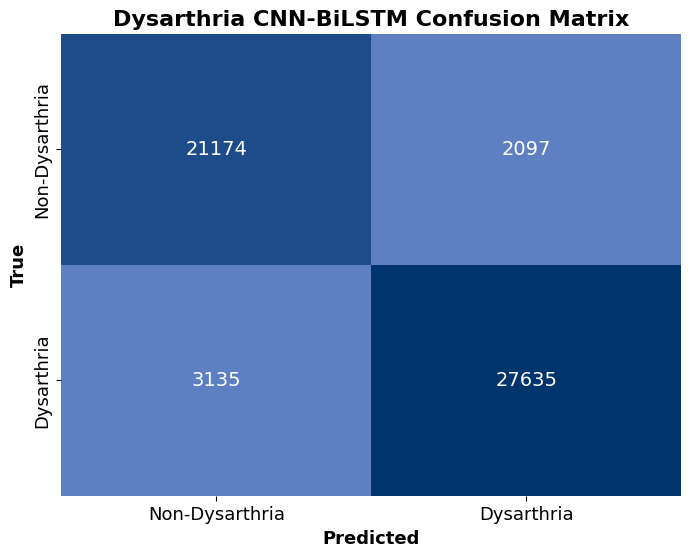

In [ ]:
# Confusion Matrix
dys_cnnbilstm_conf_matrix = confusion_matrix(y_test, dys_cnnbilstm_y_pred)

plt.figure(figsize=(8, 6))

# Make a HeatMap
sns.heatmap(dys_cnnbilstm_conf_matrix, annot=True, fmt='d', cmap=sns.color_palette(cmap), cbar=False,
            xticklabels=['Non-Dysarthria', 'Dysarthria'], yticklabels=['Non-Dysarthria', 'Dysarthria'], annot_kws={"size": 14})

# Adding title and labels
plt.title('Dysarthria CNN-BiLSTM Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted', fontsize=13, fontweight='bold')
plt.ylabel('True', fontsize=13, fontweight='bold')

# Adding ticks
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# Show Plot
plt.show()

The Dysarthria CNN-BiLSTM Confusion Matrix presents the model's classification performance. The model correctly classified 21174 non-dysarthria cases and 27635 dysarthria cases. There were 2097 false positives, where non-dysarthria was incorrectly predicted as dysarthria, and 3135 false negatives, where dysarthria was incorrectly predicted as non-dysarthria.

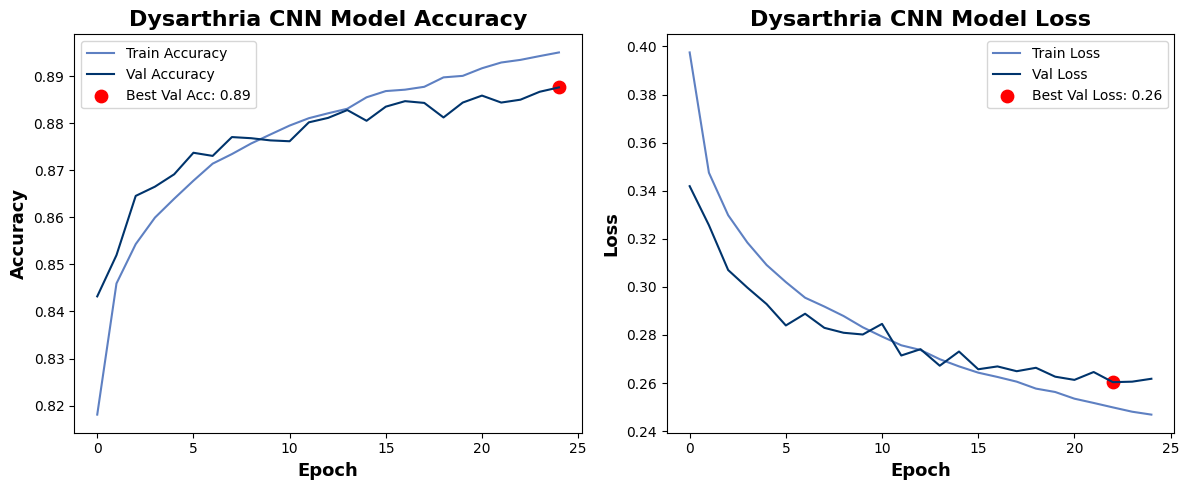

In [ ]:
# Plot training history
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(dys_cnnbilstm_history.history['accuracy'], label='Train Accuracy', color=cmap[0])
plt.plot(dys_cnnbilstm_history.history['val_accuracy'], label='Val Accuracy', color=cmap[3])

# Find best val accuracy
best_acc_epoch = np.argmax(dys_cnnbilstm_history.history['val_accuracy'])
best_acc = dys_cnnbilstm_history.history['val_accuracy'][best_acc_epoch]

# Mark best point
plt.scatter(best_acc_epoch, best_acc, color='red', s=80, label=f'Best Val Acc: {best_acc:.2f}')

# Add Title and Labels
plt.title('Dysarthria CNN Model Accuracy', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy', fontsize=13, fontweight='bold')
plt.xlabel('Epoch', fontsize=13, fontweight='bold')
plt.legend(loc='best')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(dys_cnnbilstm_history.history['loss'], label='Train Loss', color=cmap[0])
plt.plot(dys_cnnbilstm_history.history['val_loss'], label='Val Loss', color=cmap[3])

# Find best (min) val loss
best_loss_epoch = np.argmin(dys_cnnbilstm_history.history['val_loss'])
best_loss = dys_cnnbilstm_history.history['val_loss'][best_loss_epoch]

# Mark best point
plt.scatter(best_loss_epoch, best_loss, color='red', s=80, label=f'Best Val Loss: {best_loss:.2f}')

# Add Title and Labels
plt.title('Dysarthria CNN Model Loss', fontsize=16, fontweight='bold')
plt.ylabel('Loss', fontsize=13, fontweight='bold')
plt.xlabel('Epoch', fontsize=13, fontweight='bold')
plt.legend(loc='best')

# Show plot
plt.tight_layout()
plt.show()


The plot displays the training performance of the Dysarthria CNN model. The accuracy plot shows both the training and validation accuracy rising consistently, with the best validation accuracy peaking at 0.89. The loss plot indicates that both training and validation loss decrease over time, with the best validation loss reaching 0.26, suggesting that the model is learning effectively and generalizing well.

### *Dys-CnnAttBiLSTM*

A Dys-CNN-Att-BiLSTM model integrates convolutional layers, bidirectional LSTMs, and attention for dysarthria detection. CNN extracts local features from audio signals. BiLSTM captures sequential dependencies in both directions. Attention highlights critical segments, improving focus and overall classification performance.

In [ ]:
# Custom Attention Layer
class AttentionLayer(Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], input_shape[-1]),
                                 initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(name="att_bias", shape=(input_shape[-1],),
                                 initializer="zeros", trainable=True)
        self.u = self.add_weight(name="att_u", shape=(input_shape[-1], 1),
                                 initializer="glorot_uniform", trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        # Compute attention scores
        u_it = tf.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        att_scores = tf.nn.softmax(tf.tensordot(u_it, self.u, axes=1), axis=1)
        # Weighted sum
        output = tf.reduce_sum(inputs * att_scores, axis=1)
        return output

In [ ]:
# CNN Base Model
def cnn_base_model(input_shape):
    inputs = Input(shape=input_shape)

    # First convolutional block: basic feature extraction
    x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = MaxPooling1D(pool_size=2)(x)
    x = BatchNormalization()(x)

    # Second convolutional block: deeper features with increased filters
    x = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = BatchNormalization()(x)

    # Residual connection to improve gradient flow and learning
    residual = Conv1D(128, kernel_size=1, padding='same')(x)
    x = Add()([x, residual])
    x = Activation('relu')(x)

    return Model(inputs, x)

In [ ]:
# CNN-BiLSTM-Attention Model
def dys_cnn_bilstm_attention_model(input_shape):
    inputs = Input(shape=input_shape)

    # CNN feature extractor
    cnn_model = cnn_base_model(input_shape)
    x = cnn_model(inputs)

    # BiLSTM with return_sequences=True
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Dropout(0.5)(x)

    # Custom Attention
    x = AttentionLayer()(x)

    # Dense Layers
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)

    # Output Layer
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

#### _KFold Cross Validation_


In [ ]:
# K-Fold Cross Validation
fold_no = 1
for train_index, val_index in kf.split(X_mfccs):

    # Split the data
    X_train, X_val = X_mfccs[train_index], X_mfccs[val_index]
    y_train, y_val = y[train_index], y[val_index]

    # Reshape the data for Conv1D
    X_train_reshaped = X_train[..., np.newaxis]
    X_val_reshaped = X_val[..., np.newaxis]

    # Build the model
    input_shape = (X_train_reshaped.shape[1], 1)
    model = dys_cnn_bilstm_attention_model(input_shape)

    # Train the model
    history = model.fit(X_train_reshaped, y_train,
                                validation_data=(X_val_reshaped, y_val),
                                epochs=30,
                                batch_size=128,
                                verbose=1)

    # Evaluate the model
    scores = model.evaluate(X_val_reshaped, y_val, verbose=0)
    print(f"Score for fold {fold_no}: Loss = {scores[0]}; Accuracy = {scores[1] * 100}%")

    accuracy_per_fold.append(scores[1] * 100)
    loss_per_fold.append(scores[0])

    fold_no += 1

Epoch 1/30
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - accuracy: 0.7961 - loss: 0.4289 - val_accuracy: 0.8474 - val_loss: 0.3371
Epoch 2/30
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.8472 - loss: 0.3428 - val_accuracy: 0.8588 - val_loss: 0.3146
Epoch 3/30
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.8584 - loss: 0.3209 - val_accuracy: 0.8679 - val_loss: 0.2952
Epoch 4/30
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.8662 - loss: 0.3045 - val_accuracy: 0.8724 - val_loss: 0.2873
Epoch 5/30
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.8703 - loss: 0.2943 - val_accuracy: 0.8737 - val_loss: 0.2820
Epoch 6/30
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.8753 - loss: 0.2853 - val_accuracy: 0.8757 - val_loss: 0.2787
Epoch 7/30
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.8796 - loss: 0.2778 - val_accuracy: 0.8788 - val_loss: 0.2740
Epoch 8/30
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.8813 -

In [ ]:
# Print overall results
print('------------------------------------------------------------------------')
print('Score per fold')
for i in range(0, len(accuracy_per_fold)):
    print(f'> Fold {i+1} - Loss: {loss_per_fold[i]} - Accuracy: {accuracy_per_fold[i]}%')
print('------------------------------------------------------------------------')
print(f'Average accuracy for all folds: {np.mean(accuracy_per_fold)}% (+- {np.std(accuracy_per_fold)})')
print(f'Average loss for all folds: {np.mean(loss_per_fold)}')
print('------------------------------------------------------------------------')

------------------------------------------------------------------------
Score per fold
> Fold 1 - Loss: 0.26572829484939575 - Accuracy: 89.0175998210907%
> Fold 2 - Loss: 0.2634655237197876 - Accuracy: 88.93802762031555%
> Fold 3 - Loss: 0.2569127082824707 - Accuracy: 89.4357979297638%
> Fold 4 - Loss: 0.2662661373615265 - Accuracy: 88.99334073066711%
> Fold 5 - Loss: 0.26506856083869934 - Accuracy: 89.15063142776489%
------------------------------------------------------------------------
Average accuracy for all folds: 89.10707950592041% (+- 0.17859128483233938)
Average loss for all folds: 0.263488245010376
------------------------------------------------------------------------


The model obtained an average accuracy of 89.11% with variability of plus minus 0.18 and maintained an average loss of 0.26, indicating highly consistent performance and improved generalisation across folds.


#### _Train and Evaluate Model_


In [ ]:
# Define input_shape
input_shape = (13, 1)

# Build the model
dys_cnn_att_bilstm_model = dys_cnn_bilstm_attention_model(input_shape)

In [ ]:
# Train the model
dys_cnn_att_bilstm_history = dys_cnn_att_bilstm_model.fit(X_train, y_train, epochs=25, batch_size=32,validation_data=(X_val, y_val),verbose=1)

Epoch 1/25
6756/6756 ━━━━━━━━━━━━━━━━━━━━ 91s 12ms/step - accuracy: 0.7954 - loss: 0.4338 - val_accuracy: 0.8510 - val_loss: 0.3400
Epoch 2/25
6756/6756 ━━━━━━━━━━━━━━━━━━━━ 84s 12ms/step - accuracy: 0.8414 - loss: 0.3524 - val_accuracy: 0.8584 - val_loss: 0.3181
Epoch 3/25
6756/6756 ━━━━━━━━━━━━━━━━━━━━ 85s 13ms/step - accuracy: 0.8546 - loss: 0.3290 - val_accuracy: 0.8592 - val_loss: 0.3152
Epoch 4/25
6756/6756 ━━━━━━━━━━━━━━━━━━━━ 83s 12ms/step - accuracy: 0.8610 - loss: 0.3146 - val_accuracy: 0.8682 - val_loss: 0.2984
Epoch 5/25
6756/6756 ━━━━━━━━━━━━━━━━━━━━ 84s 12ms/step - accuracy: 0.8662 - loss: 0.3043 - val_accuracy: 0.8720 - val_loss: 0.2875
Epoch 6/25
6756/6756 ━━━━━━━━━━━━━━━━━━━━ 83s 12ms/step - accuracy: 0.8685 - loss: 0.2990 - val_accuracy: 0.8720 - val_loss: 0.2857
Epoch 7/25
6756/6756 ━━━━━━━━━━━━━━━━━━━━ 83s 12ms/step - accuracy: 0.8745 - loss: 0.2891 - val_accuracy: 0.8715 - val_loss: 0.2910
Epoch 8/25
6756/6756 ━━━━━━━━━━━━━━━━━━━━ 82s 12ms/step - accuracy: 0.8756 -

In [ ]:
# Predictions on the test set
dys_cnn_att_bilstm_y_pred_prob = dys_cnn_att_bilstm_model.predict(X_test)
dys_cnn_att_bilstm_y_pred = np.round(dys_cnn_att_bilstm_y_pred_prob).astype(int)

1689/1689 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


In [ ]:
# lassification report
dys_cnn_att_bilstm_report = classification_report(y_test, dys_cnn_att_bilstm_y_pred, target_names=['Non-Dysarthria', 'Dysarthria'], output_dict=True)

In [ ]:
# Extract metrics
dys_cnn_att_bilstm_accuracy = accuracy_score(y_test, dys_cnn_att_bilstm_y_pred)
dys_cnn_att_bilstm_precision = dys_cnn_att_bilstm_report['Dysarthria']['precision']
dys_cnn_att_bilstm_recall = dys_cnn_att_bilstm_report['Dysarthria']['recall']
dys_cnn_att_bilstm_f1 = dys_cnn_att_bilstm_report['Dysarthria']['f1-score']
dys_cnn_att_bilstm_log_loss = log_loss(y_test, dys_cnn_att_bilstm_y_pred_prob)

In [ ]:
# Print results
print("Dysarthria CnnAttBiLSTM Model Results")
print(f"Accuracy: {dys_cnn_att_bilstm_accuracy:.4f}")
print(f"Precision: {dys_cnn_att_bilstm_precision:.4f}")
print(f"Recall: {dys_cnn_att_bilstm_recall:.4f}")
print(f"F1 Score: {dys_cnn_att_bilstm_f1:.4f}")
print(f"Log Loss: {dys_cnn_att_bilstm_log_loss:.4f}")

Dysarthria CnnAttBiLSTM Model Results
Accuracy: 0.9057
Precision: 0.9190
Recall: 0.9151
F1 Score: 0.9171
Log Loss: 0.2194


The Dysarthria CNN-Att-BiLSTM model achieved accuracy of 0.9057, precision of 0.9190, recall of 0.9151, and F1 score of 0.9171, with log loss of 0.2194, reflecting superior balance and robust classification capability.


In [ ]:
# Print Report
print(classification_report(y_test, dys_cnn_att_bilstm_y_pred, target_names=['Non-Dysarthria', 'Dysarthria']))

                precision    recall  f1-score   support

Non-Dysarthria       0.89      0.89      0.89     23271
    Dysarthria       0.92      0.92      0.92     30770

      accuracy                           0.91     54041
     macro avg       0.90      0.90      0.90     54041
  weighted avg       0.91      0.91      0.91     54041



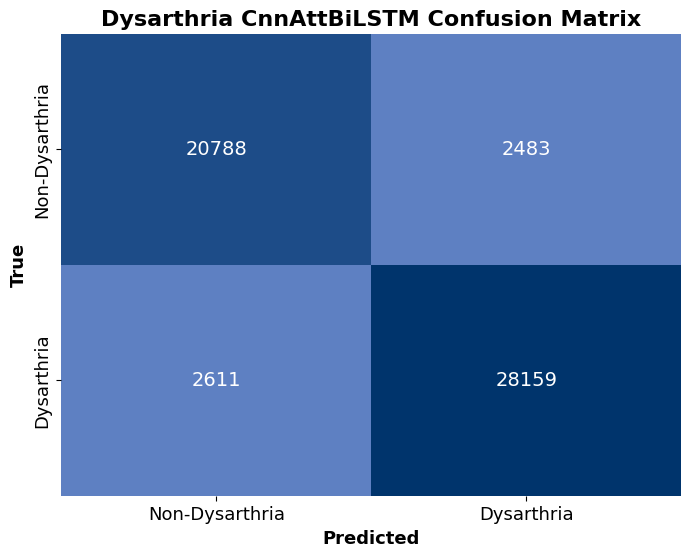

In [ ]:
# Confusion Matrix
dys_cnn_att_bilstm_conf_matrix = confusion_matrix(y_test, dys_cnn_att_bilstm_y_pred)

plt.figure(figsize=(8, 6))

# Make a HeatMap
sns.heatmap(dys_cnn_att_bilstm_conf_matrix, annot=True, fmt='d', cmap=sns.color_palette(cmap), cbar=False,
            xticklabels=['Non-Dysarthria', 'Dysarthria'], yticklabels=['Non-Dysarthria', 'Dysarthria'], annot_kws={"size": 14})

# Adding title and labels
plt.title('Dysarthria CnnAttBiLSTM Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted', fontsize=13, fontweight='bold')
plt.ylabel('True', fontsize=13, fontweight='bold')

# Adding ticks
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# Show Plot
plt.show()

The Dysarthria CnnAttBiLSTM Confusion Matrix shows the model's classification results. The model correctly classified 20788 non-dysarthria cases and 28159 dysarthria cases. It made 2483 false positive errors, where non-dysarthria was incorrectly identified as dysarthria, and 2611 false negative errors, where dysarthria was incorrectly identified as non-dysarthria.

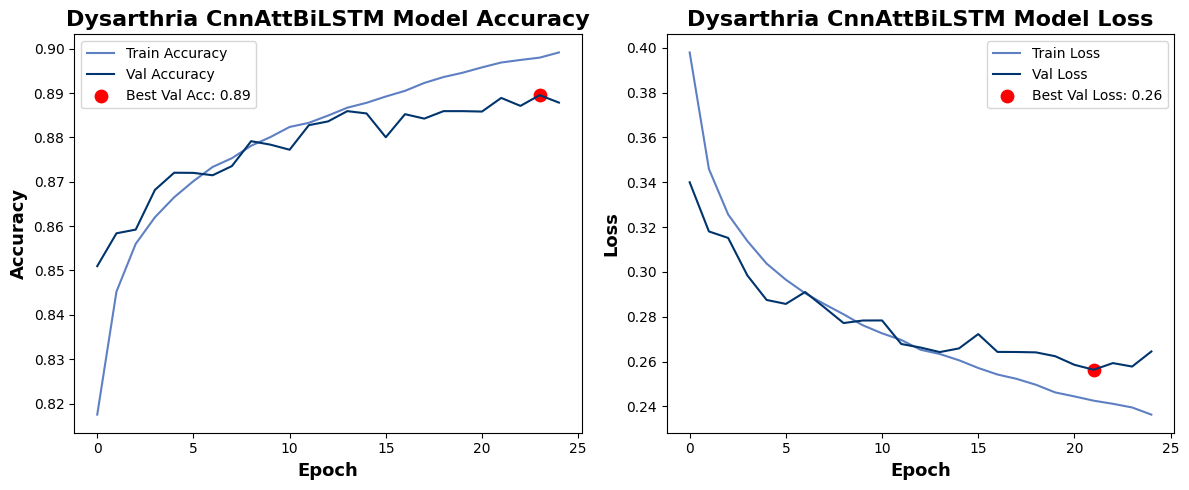

In [ ]:
# Plot training history
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(dys_cnn_att_bilstm_history.history['accuracy'], label='Train Accuracy', color=cmap[0])
plt.plot(dys_cnn_att_bilstm_history.history['val_accuracy'], label='Val Accuracy', color=cmap[3])

# Find best val accuracy
best_acc_epoch = np.argmax(dys_cnn_att_bilstm_history.history['val_accuracy'])
best_acc = dys_cnn_att_bilstm_history.history['val_accuracy'][best_acc_epoch]

# Mark best point
plt.scatter(best_acc_epoch, best_acc, color='red', s=80, label=f'Best Val Acc: {best_acc:.2f}')

# Add Title and Labels
plt.title('Dysarthria CnnAttBiLSTM Model Accuracy', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy', fontsize=13, fontweight='bold')
plt.xlabel('Epoch', fontsize=13, fontweight='bold')
plt.legend(loc='best')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(dys_cnn_att_bilstm_history.history['loss'], label='Train Loss', color=cmap[0])
plt.plot(dys_cnn_att_bilstm_history.history['val_loss'], label='Val Loss', color=cmap[3])

# Find best (min) val loss
best_loss_epoch = np.argmin(dys_cnn_att_bilstm_history.history['val_loss'])
best_loss = dys_cnn_att_bilstm_history.history['val_loss'][best_loss_epoch]

# Mark best point
plt.scatter(best_loss_epoch, best_loss, color='red', s=80, label=f'Best Val Loss: {best_loss:.2f}')

# Add Title and Labels
plt.title('Dysarthria CnnAttBiLSTM Model Loss', fontsize=16, fontweight='bold')
plt.ylabel('Loss', fontsize=13, fontweight='bold')
plt.xlabel('Epoch', fontsize=13, fontweight='bold')
plt.legend(loc='best')

# Show plot
plt.tight_layout()
plt.show()

The plot display the training progression of the Dysarthria CnnAttBiLSTM model. The accuracy plot shows that the training and validation accuracy both increase, with the best validation accuracy reaching 0.89. The loss plot illustrates a consistent decrease in both training and validation loss, with the best validation loss reaching 0.26, indicating successful model learning and generalization.

### *Ensemble Model*

An ensemble model is a machine learning approach that combines predictions from multiple individual models to produce a more accurate and robust final prediction, similar to seeking the "wisdom of crowds".

In [ ]:
# Average the probabilities
ensemble_probs = (dys_cnn_y_pred_prob + dys_cnnbilstm_y_pred_prob + dys_cnn_att_bilstm_y_pred_prob) / 3

# Convert probabilities to binary
ensemble_preds = (ensemble_probs > 0.5).astype(int)

In [ ]:
# Classification report
ensemble_report = classification_report(y_test, ensemble_preds, target_names=['Non-Dysarthria', 'Dysarthria'], output_dict=True)

In [ ]:
# Extract metrics
ensemble_accuracy = accuracy_score(y_test, ensemble_preds)
ensemble_precision = ensemble_report['Dysarthria']['precision']
ensemble_recall = ensemble_report['Dysarthria']['recall']
ensemble_f1 = ensemble_report['Dysarthria']['f1-score']
ensemble_log_loss_val = log_loss(y_test, ensemble_probs)

In [ ]:
# Print results
print("Dysarthria Ensemble Model Results")
print(f"Accuracy: {ensemble_accuracy:.4f}")
print(f"Precision: {ensemble_precision:.4f}")
print(f"Recall: {ensemble_recall:.4f}")
print(f"F1 Score: {ensemble_f1:.4f}")
print(f"Log Loss: {ensemble_log_loss_val:.4f}")

Dysarthria Ensemble Model Results
Accuracy: 0.9066
Precision: 0.9293
Recall: 0.9047
F1 Score: 0.9168
Log Loss: 0.2268


The Dysarthria Ensemble model achieved accuracy of 0.9066, precision of 0.9293, recall of 0.9047, and F1 score of 0.9168, with log loss of 0.2268, demonstrating strong robustness and balanced classification effectiveness.


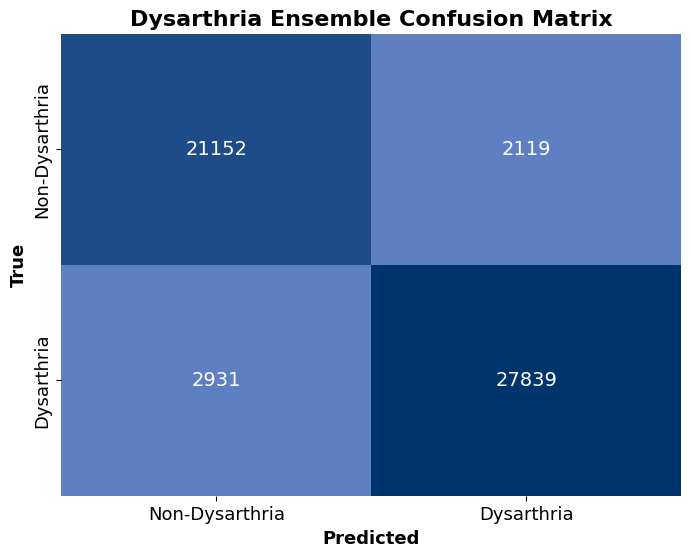

In [ ]:
# Confusion Matrix
dys_ens_conf_matrix = confusion_matrix(y_test, ensemble_preds)

plt.figure(figsize=(8, 6))

# Make a HeatMap
sns.heatmap(dys_ens_conf_matrix, annot=True, fmt='d', cmap=sns.color_palette(cmap), cbar=False,
            xticklabels=['Non-Dysarthria', 'Dysarthria'], yticklabels=['Non-Dysarthria', 'Dysarthria'], annot_kws={"size": 14})

# Adding title and labels
plt.title('Dysarthria Ensemble Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted', fontsize=13, fontweight='bold')
plt.ylabel('True', fontsize=13, fontweight='bold')

# Adding ticks
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# Show Plot
plt.show()

The Dysarthria Ensemble Confusion Matrix shows the model's classification performance. The model correctly predicted 21152 non-dysarthria cases and 27839 dysarthria cases. There were 2119 false positives, where non-dysarthria was incorrectly classified as dysarthria, and 2931 false negatives, where dysarthria was incorrectly classified as non-dysarthria.

## *Plot Comparison*

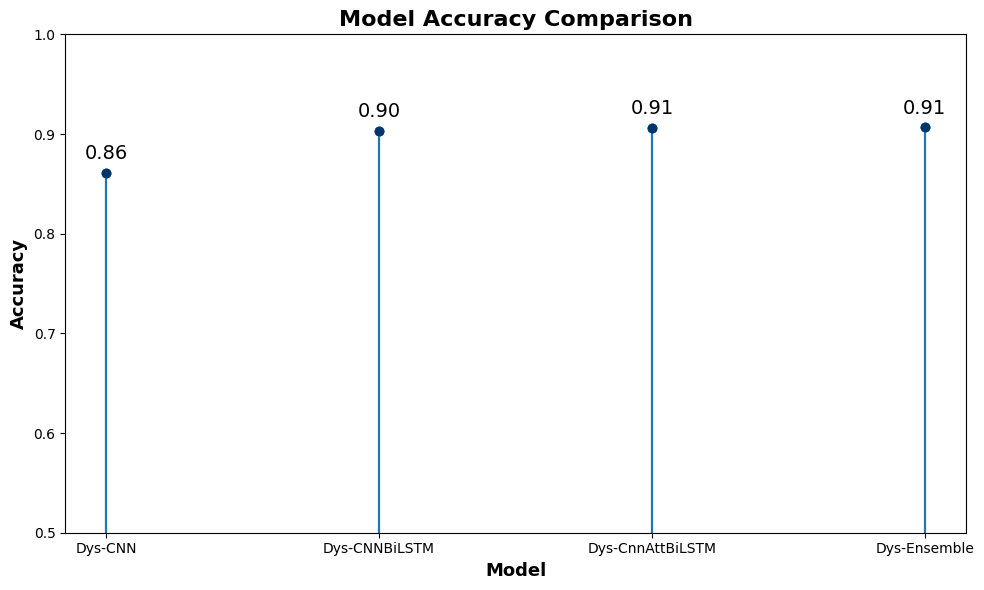

In [ ]:
# Define metrics
model_names = ['Dys-CNN', 'Dys-CNNBiLSTM', 'Dys-CnnAttBiLSTM', 'Dys-Ensemble']
accuracies = [dys_cnn_accuracy, dys_cnnbilstm_accuracy,dys_cnn_att_bilstm_accuracy, ensemble_accuracy]

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Stem plot for each model
ax.stem(model_names, accuracies, linefmt='-', markerfmt='o', basefmt=' ', use_line_collection=True)

# Set the marker color and line color
plt.setp(ax.stem(model_names, accuracies)[1], color=colours[0])  # Marker color
plt.setp(ax.stem(model_names, accuracies)[0], color=colours[3])  # Line color

# Adding Annotations
for i, (model, accuracy) in enumerate(zip(model_names, accuracies)):
    ax.text(i, accuracy + 0.01, f'{accuracy:.2f}', ha='center', va='bottom', fontsize=14)

# Add labels and title
ax.set_title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
ax.set_xlabel('Model', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=13, fontweight='bold')

# Set y-axis limit
ax.set_ylim(0.5, 1.0)

# Show plot
plt.tight_layout()
plt.show()

The Model Accuracy Comparison chart shows the performance of four models. Dys-CNN has an accuracy of 0.86. The Dys-CNNBiLSTM and Dys-CnnAttBiLSTM models have higher accuracies of 0.90 and 0.91 respectively. The Dys-Ensemble model achieves the highest accuracy at 0.91.

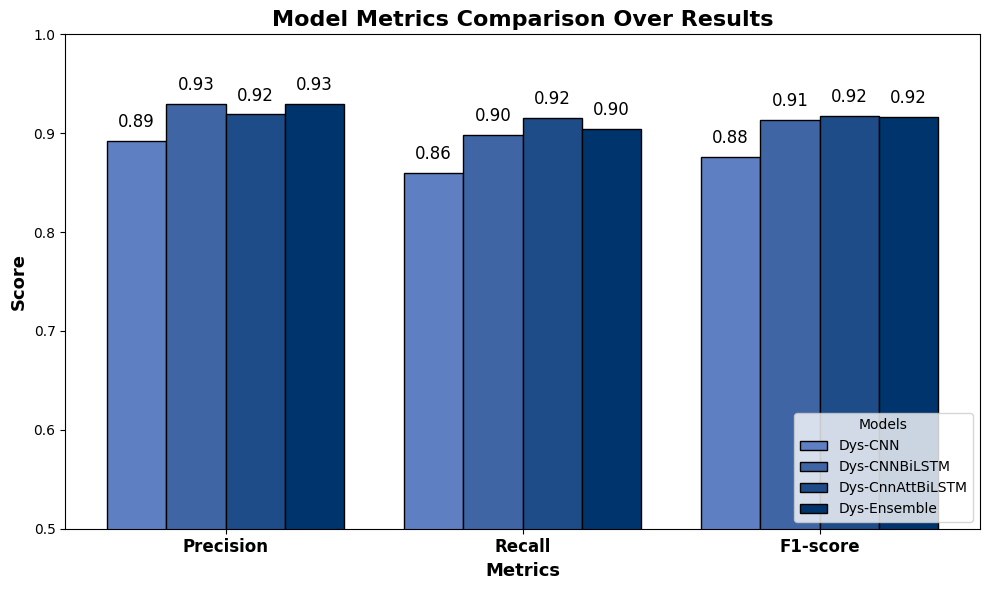

In [ ]:
# Define the metrics for CNN, Hybrid, and Ensemble models
metrics = ['Precision', 'Recall', 'F1-score']

# Metric values for each model
data = np.array([
    [dys_cnn_precision, dys_cnn_recall, dys_cnn_f1],
    [dys_cnnbilstm_precision, dys_cnnbilstm_recall, dys_cnnbilstm_f1],
    [dys_cnn_att_bilstm_precision, dys_cnn_att_bilstm_recall, dys_cnn_att_bilstm_f1],
    [ensemble_precision, ensemble_recall, ensemble_f1]
])

# Create grouped bar plot
x = np.arange(len(metrics))
bar_width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars for each model
for i, model in enumerate(model_names):
    ax.bar(x + i * bar_width, data[i], width=bar_width, color=colours[i % len(colours)], label=model, edgecolor='black')

# Adding annotations
for i, model in enumerate(model_names):
    for j, val in enumerate(data[i]):
        ax.text(x[j] + i * bar_width, val + 0.01, f"{val:.2f}",
                ha='center', va='bottom', fontsize=12)


# Add title and legends
ax.set_title("Model Metrics Comparison Over Results", fontsize=16, fontweight="bold")
ax.set_ylabel("Score", fontsize=13, fontweight="bold")
ax.set_xlabel("Metrics", fontsize=13, fontweight="bold")

# Add ticks
ax.set_xticks(x + bar_width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metrics, fontsize=12, fontweight="bold")

# Set y-axis limit
ax.set_ylim(0.5, 1.0)

# Add legend
ax.legend(title="Models", loc='lower right')

# Show plot
plt.tight_layout()
plt.show()


The bar chart compares the precision, recall, and F1-score of four models. For precision, the Dys-CNN scores 0.89, while the other three models score higher at 0.93 and 0.92. For recall, Dys-CNN scores 0.86, whereas the others are higher at 0.90 and 0.92. The F1-score for Dys-CNN is 0.88, while the others are 0.91 and 0.92.

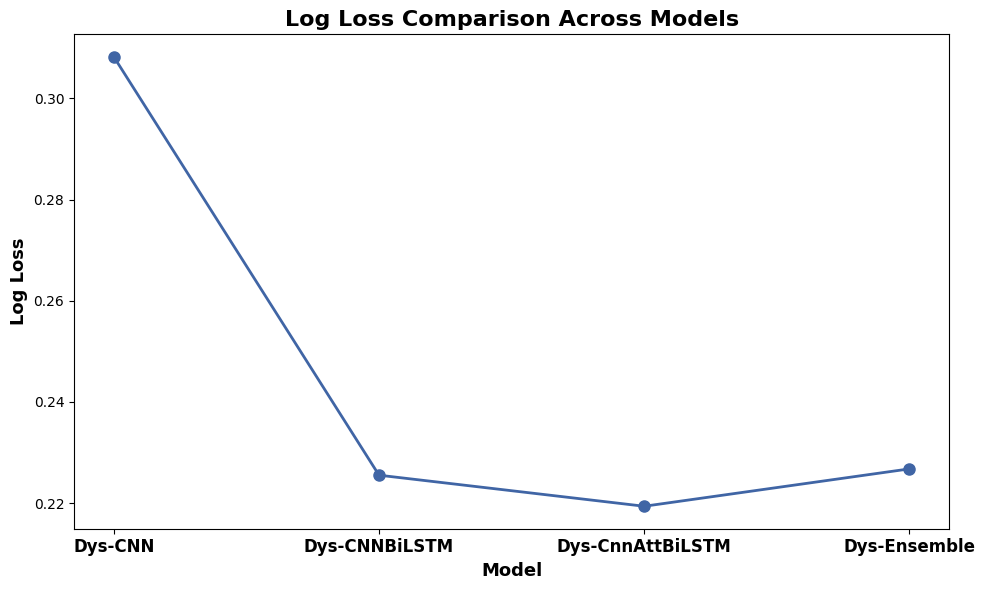

In [ ]:
log_loss_values = [dys_cnn_log_loss, dys_cnnbilstm_log_loss,dys_cnn_att_bilstm_log_loss, ensemble_log_loss_val]

fig, ax = plt.subplots(figsize=(10, 6))

# Plot the log loss values
ax.plot(model_names, log_loss_values, marker='o', color=colours[1], markersize=8, linestyle='-', linewidth=2)

# Add title and labels
ax.set_title('Log Loss Comparison Across Models', fontsize=16, fontweight='bold')
ax.set_xlabel('Model', fontsize=13, fontweight='bold')
ax.set_ylabel('Log Loss', fontsize=13, fontweight='bold')

# Add ticks
ax.set_xticks(np.arange(len(model_names)))
ax.set_xticklabels(model_names, fontsize=12, fontweight="bold")

# Show plot
plt.tight_layout()
plt.show()

The Log Loss Comparison shows the performance of four models. Dys-CNN has the highest loss at 0.31. The Dys-CNNBiLSTM and Dys-CnnAttBiLSTM models have much lower losses at 0.226 and 0.22, respectively. The Dys-Ensemble model has a slightly higher loss of 0.227.

In [ ]:
# Save CSV
import pandas as pd

# Create a dictionary of results
results = {
    "Model": ["Dys-CNN", "Dys-CNNBiLSTM", "Dys-CnnAttBiLSTM", "Dys-Ensemble"],
    "Accuracy": [dys_cnn_accuracy, dys_cnnbilstm_accuracy, dys_cnn_att_bilstm_accuracy, ensemble_accuracy],
    "Precision": [dys_cnn_precision, dys_cnnbilstm_precision, dys_cnn_att_bilstm_precision, ensemble_precision],
    "Recall": [dys_cnn_recall, dys_cnnbilstm_recall, dys_cnn_att_bilstm_recall, ensemble_recall],
    "F1-score": [dys_cnn_f1, dys_cnnbilstm_f1, dys_cnn_att_bilstm_f1, ensemble_f1],
    "Log Loss": [dys_cnn_log_loss, dys_cnnbilstm_log_loss, dys_cnn_att_bilstm_log_loss, ensemble_log_loss_val]
}

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Save to CSV
results_df.to_csv("dys_model_results.csv", index=False)
results_df.head()

,Model,Accuracy,Precision,Recall,F1-score,Log Loss
0,Dys-CNN,0.861291,0.892452,0.860026,0.875939,0.308220
1,Dys-CNNBiLSTM,0.903185,0.929470,0.898115,0.913524,0.225525
2,Dys-CnnAttBiLSTM,0.905738,0.918967,0.915145,0.917052,0.219385
3,Dys-Ensemble,0.906552,0.929268,0.904745,0.916842,0.226772


In [ ]:
# Save model
dys_cnn_att_bilstm_model.save_weights('best_model.weights.h5')

### *ROC Curve*

In [ ]:
from sklearn.metrics import roc_curve, auc

In [ ]:
# Compute ROC curve and AUC for each model
fpr_dys_cnn, tpr_dys_cnn, _ = roc_curve(y_test, dys_cnn_y_pred_prob)
roc_auc_dys_cnn = auc(fpr_dys_cnn, tpr_dys_cnn)

fpr_dys_cnnbilstm, tpr_dys_cnnbilstm, _ = roc_curve(y_test, dys_cnnbilstm_y_pred_prob)
roc_auc_dys_cnnbilstm = auc(fpr_dys_cnnbilstm, tpr_dys_cnnbilstm)

fpr_dys_cnn_att_bilstm, tpr_dys_cnn_att_bilstm, _ = roc_curve(y_test, dys_cnn_att_bilstm_y_pred_prob)
roc_auc_dys_cnn_att_bilstm = auc(fpr_dys_cnn_att_bilstm, tpr_dys_cnn_att_bilstm)

fpr_ensemble, tpr_ensemble, _ = roc_curve(y_test, ensemble_probs)
roc_auc_ensemble = auc(fpr_ensemble, tpr_ensemble)

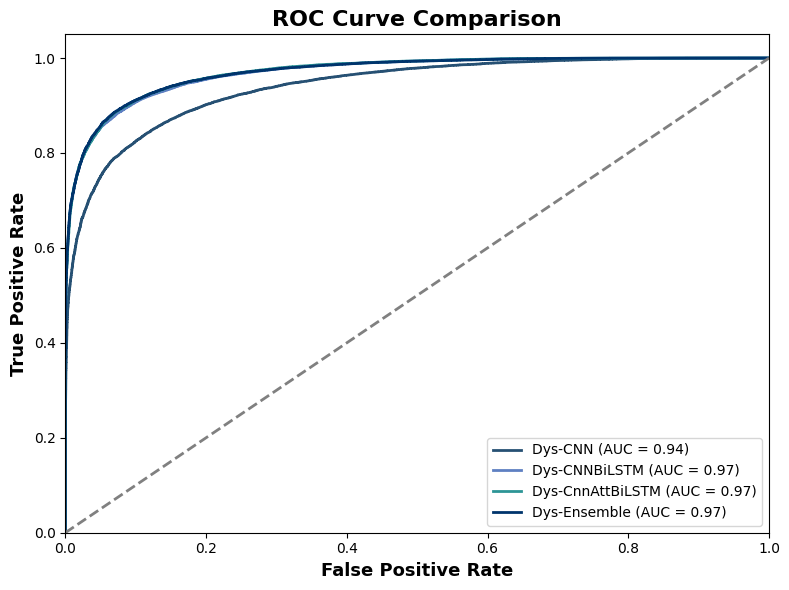

In [ ]:
# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_dys_cnn, tpr_dys_cnn, color='#265073', lw=2, label=f'Dys-CNN (AUC = {roc_auc_dys_cnn:.2f})')
plt.plot(fpr_dys_cnnbilstm, tpr_dys_cnnbilstm, color='#5e80c2', lw=2, label=f'Dys-CNNBiLSTM (AUC = {roc_auc_dys_cnnbilstm:.2f})')
plt.plot(fpr_dys_cnn_att_bilstm, tpr_dys_cnn_att_bilstm, color='#2D9596', lw=2, label=f'Dys-CnnAttBiLSTM (AUC = {roc_auc_dys_cnn_att_bilstm:.2f})')
plt.plot(fpr_ensemble, tpr_ensemble, color='#00346c', lw=2, label=f'Dys-Ensemble (AUC = {roc_auc_ensemble:.2f})')

# Plot the diagonal line for random chance
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')


# Add title and labels
plt.title('ROC Curve Comparison', fontsize=16, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')

# Add limit
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Add legend
plt.legend(loc="lower right")

# Show plot
plt.tight_layout()
plt.show()

The ROC Curve Comparison chart evaluates the performance of four models. Dys-CNN has an Area Under Curve AUC of 0.94. The Dys-CNNBiLSTM, Dys-CnnAttBiLSTM, and Dys-Ensemble models all have a higher AUC of 0.97. These curves show that all models perform significantly better than random chance, which is represented by the dotted line. The three advanced models are superior to the basic CNN.

### *Precision-Recall Curve*

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

In [ ]:
# Compute Precision-Recall curve for each model
precision_dys_cnn, recall_dys_cnn, _ = precision_recall_curve(y_test, dys_cnn_y_pred_prob)
average_precision_dys_cnn = average_precision_score(y_test, dys_cnn_y_pred_prob)

precision_dys_cnnbilstm, recall_dys_cnnbilstm, _ = precision_recall_curve(y_test, dys_cnnbilstm_y_pred_prob)
average_precision_dys_cnnbilstm = average_precision_score(y_test, dys_cnnbilstm_y_pred_prob)

precision_dys_cnn_att_bilstm, recall_dys_cnn_att_bilstm, _ = precision_recall_curve(y_test, dys_cnn_att_bilstm_y_pred_prob)
average_precision_dys_cnn_att_bilstm = average_precision_score(y_test, dys_cnn_att_bilstm_y_pred_prob)

precision_ensemble, recall_ensemble, _ = precision_recall_curve(y_test, ensemble_probs)
average_precision_ensemble = average_precision_score(y_test, ensemble_probs)

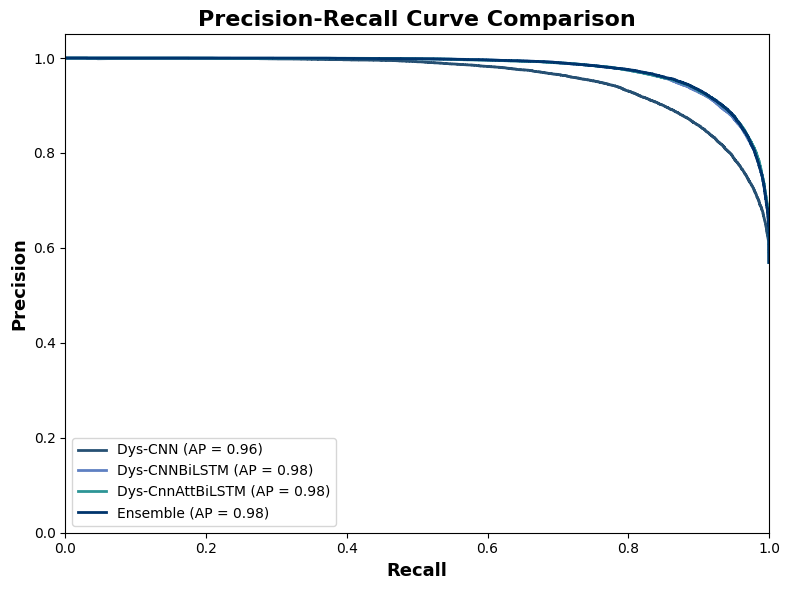

In [ ]:
# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_dys_cnn, precision_dys_cnn, color='#265073', lw=2, label=f'Dys-CNN (AP = {average_precision_dys_cnn:.2f})')
plt.plot(recall_dys_cnnbilstm, precision_dys_cnnbilstm, color='#5e80c2', lw=2, label=f'Dys-CNNBiLSTM (AP = {average_precision_dys_cnnbilstm:.2f})')
plt.plot(recall_dys_cnn_att_bilstm, precision_dys_cnn_att_bilstm, color='#2D9596', lw=2, label=f'Dys-CnnAttBiLSTM (AP = {average_precision_dys_cnn_att_bilstm:.2f})')
plt.plot(recall_ensemble, precision_ensemble, color='#00346c', lw=2, label=f'Ensemble (AP = {average_precision_ensemble:.2f})')

# Add labels and title
plt.title('Precision-Recall Curve Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Recall', fontsize=13, fontweight='bold')
plt.ylabel('Precision', fontsize=13, fontweight='bold')

#Add limit
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Add legend
plt.legend(loc="lower left")

# Show plot
plt.tight_layout()
plt.show()

The Precision-Recall Curve Comparison chart evaluates model performance. The Dys-CNN model has an Average Precision AP of 0.96. The Dys-CNNBiLSTM, Dys-CnnAttBiLSTM, and Ensemble models all demonstrate a higher AP of 0.98. The curves show that all models maintain high precision across different recall levels, but the three advanced models are superior to the basic CNN.

## *Conclusion*

The experimental results highlight that the **Dysarthria Ensemble model** delivered the best overall performance with accuracy of 0.9066, precision of 0.9293, recall of 0.9047, F1 score of 0.9168, and the lowest log loss of 0.2194 recorded by the CNN-Att-BiLSTM. These outcomes demonstrate the strength of combining models to achieve robust and balanced classification with consistent generalisation.

However, not all model variations performed successfully. Some earlier attempts such as CNN with SE blocks and attention-only approaches struggled to exceed 40 percent accuracy. These limitations highlight that not every architecture is well-suited for dysarthria detection and underscore the importance of carefully designing models that align with the complexity of speech disorder recognition.
